In [1]:
import pandas as pd
import numpy as np
from datetime import datetime, timedelta
import random

np.random.seed(42)
random.seed(42)

# ============================================
# ГЕНЕРАЦИЯ 500 ЗАПИСЕЙ ПРОФИЛИРОВАНИЯ
# ============================================

n_records = 500

# Операции и их параметры (analyze_conflicts - проблемная с N+1)
operations = {
    'analyze_conflicts': {
        'base_ms': 450, 
        'n_queries': 1001,  # ПРОБЛЕМА N+1: 1 запрос на студентов + N на каждого
        'description': 'проблемная (N+1)'
    },
    'get_student_grades': {
        'base_ms': 12, 
        'n_queries': 2,
        'description': 'нормальная'
    },
    'get_group_report': {
        'base_ms': 25, 
        'n_queries': 21,  # Тоже небольшая проблема N+1
        'description': 'умеренная проблема'
    },
    'add_grade': {
        'base_ms': 5, 
        'n_queries': 1,
        'description': 'быстрая'
    },
    'get_student_average': {
        'base_ms': 6, 
        'n_queries': 1,
        'description': 'быстрая'
    },
    'get_teacher_subjects': {
        'base_ms': 8, 
        'n_queries': 1,
        'description': 'быстрая'
    },
    'get_subject_stats': {
        'base_ms': 10, 
        'n_queries': 2,
        'description': 'нормальная'
    }
}

# Размеры данных (количество студентов)
data_sizes = [50, 100, 200, 300, 500]

# Время суток (влияет на нагрузку)
hours = list(range(8, 20))  # 8:00 - 19:59
peak_hours = [10, 11, 12, 14, 15, 16]  # часы пик

# Генерация записей
records = []

for i in range(n_records):
    # Выбираем операцию (analyze_conflicts - 50%, остальные равномерно)
    if random.random() < 0.5:
        op_name = 'analyze_conflicts'
    else:
        op_name = random.choice([op for op in operations.keys() if op != 'analyze_conflicts'])
    
    op_config = operations[op_name]
    
    # Выбираем размер данных
    data_size = random.choice(data_sizes)
    
    # Время выполнения зависит от:
    # 1. Базового времени операции
    duration = op_config['base_ms']
    
    # 2. Размера данных (для analyze_conflicts зависимость сильнее из-за N+1)
    if op_name == 'analyze_conflicts':
        # Проблема N+1: время линейно зависит от количества студентов
        duration += (data_size / 100) * 80
    elif op_name == 'get_group_report':
        duration += (data_size / 100) * 15
    else:
        duration += (data_size / 100) * 3
    
    # 3. Часа пик (нагрузка на сервер)
    hour = random.choice(hours)
    if hour in peak_hours:
        duration *= random.uniform(1.2, 1.5)
    
    # 4. Случайные колебания
    duration += random.uniform(-10, 30)
    duration = max(1, round(duration, 2))
    
    # Количество запросов к БД
    if op_name == 'analyze_conflicts':
        n_queries = 1 + data_size  # 1 на список студентов + N на каждого
    elif op_name == 'get_group_report':
        n_queries = 1 + data_size // 50
    else:
        n_queries = op_config['n_queries']
    
    # Дата и время
    date = datetime(2025, random.randint(1, 3), random.randint(1, 28), hour, random.randint(0, 59), random.randint(0, 59))
    
    records.append({
        'measurement_id': i + 1,
        'timestamp': date.isoformat(),
        'operation_name': op_name,
        'duration_ms': duration,
        'data_size': data_size,
        'n_queries': n_queries,
        'is_peak_hour': 1 if hour in peak_hours else 0,
        'server_load': round(random.uniform(0.1, 0.9), 3)
    })

# Создаем DataFrame
df = pd.DataFrame(records)

print("=" * 70)
print("СГЕНЕРИРОВАННЫЙ ДАТАСЕТ ПРОФИЛИРОВАНИЯ (500 записей)")
print("=" * 70)
print(f"Всего записей: {len(df)}")
print(f"Операций: {df['operation_name'].unique()}")
print("\nПервые 10 строк:")
print(df.head(10))
print("\n")

print("=" * 70)
print("СТАТИСТИКА ПО ОПЕРАЦИЯМ")
print("=" * 70)
stats = df.groupby('operation_name').agg({
    'duration_ms': ['count', 'mean', 'std', 'min', 'max'],
    'n_queries': 'mean'
}).round(2)
print(stats)
print("\n")

print("=" * 70)
print("РАСПРЕДЕЛЕНИЕ ЗАПИСЕЙ")
print("=" * 70)
print(df['operation_name'].value_counts())
print("\n")

print("=" * 70)
print("КОРРЕЛЯЦИЯ С ДЛИТЕЛЬНОСТЬЮ")
print("=" * 70)
correlations = df[['duration_ms', 'data_size', 'n_queries', 'is_peak_hour', 'server_load']].corr()['duration_ms']
print(correlations.round(3))

# Сохраняем в CSV
df.to_csv('profile_data_before_optimization.csv', index=False)
print("\n✅ Датасет сохранен в 'profile_data_before_optimization.csv'")

СГЕНЕРИРОВАННЫЙ ДАТАСЕТ ПРОФИЛИРОВАНИЯ (500 записей)
Всего записей: 500
Операций: <StringArray>
[  'get_student_grades',    'analyze_conflicts', 'get_teacher_subjects',
            'add_grade',  'get_student_average',    'get_subject_stats',
     'get_group_report']
Length: 7, dtype: str

Первые 10 строк:
   measurement_id            timestamp        operation_name  duration_ms  \
0               1  2025-03-24T11:57:34    get_student_grades        42.26   
1               2  2025-03-20T09:01:35     analyze_conflicts       488.75   
2               3  2025-01-25T11:51:10  get_teacher_subjects        23.82   
3               4  2025-01-13T11:06:22     analyze_conflicts       791.66   
4               5  2025-01-18T16:18:53    get_student_grades        52.88   
5               6  2025-01-25T11:18:05             add_grade        20.06   
6               7  2025-02-12T15:13:42   get_student_average        21.28   
7               8  2025-03-24T17:15:10     get_subject_stats        26.90   


1. ПЕРВЫЙ ВЗГЛЯД НА ДАННЫЕ
Размер датасета: (500, 8)
Количество строк: 500
Количество столбцов: 8

Столбцы: ['measurement_id', 'timestamp', 'operation_name', 'duration_ms', 'data_size', 'n_queries', 'is_peak_hour', 'server_load']

Типы данных:
measurement_id      int64
timestamp             str
operation_name        str
duration_ms       float64
data_size           int64
n_queries           int64
is_peak_hour        int64
server_load       float64
dtype: object

Первые 5 строк:
   measurement_id            timestamp        operation_name  duration_ms  \
0               1  2025-03-24T11:57:34    get_student_grades        42.26   
1               2  2025-03-20T09:01:35     analyze_conflicts       488.75   
2               3  2025-01-25T11:51:10  get_teacher_subjects        23.82   
3               4  2025-01-13T11:06:22     analyze_conflicts       791.66   
4               5  2025-01-18T16:18:53    get_student_grades        52.88   

   data_size  n_queries  is_peak_hour  server_load  
0

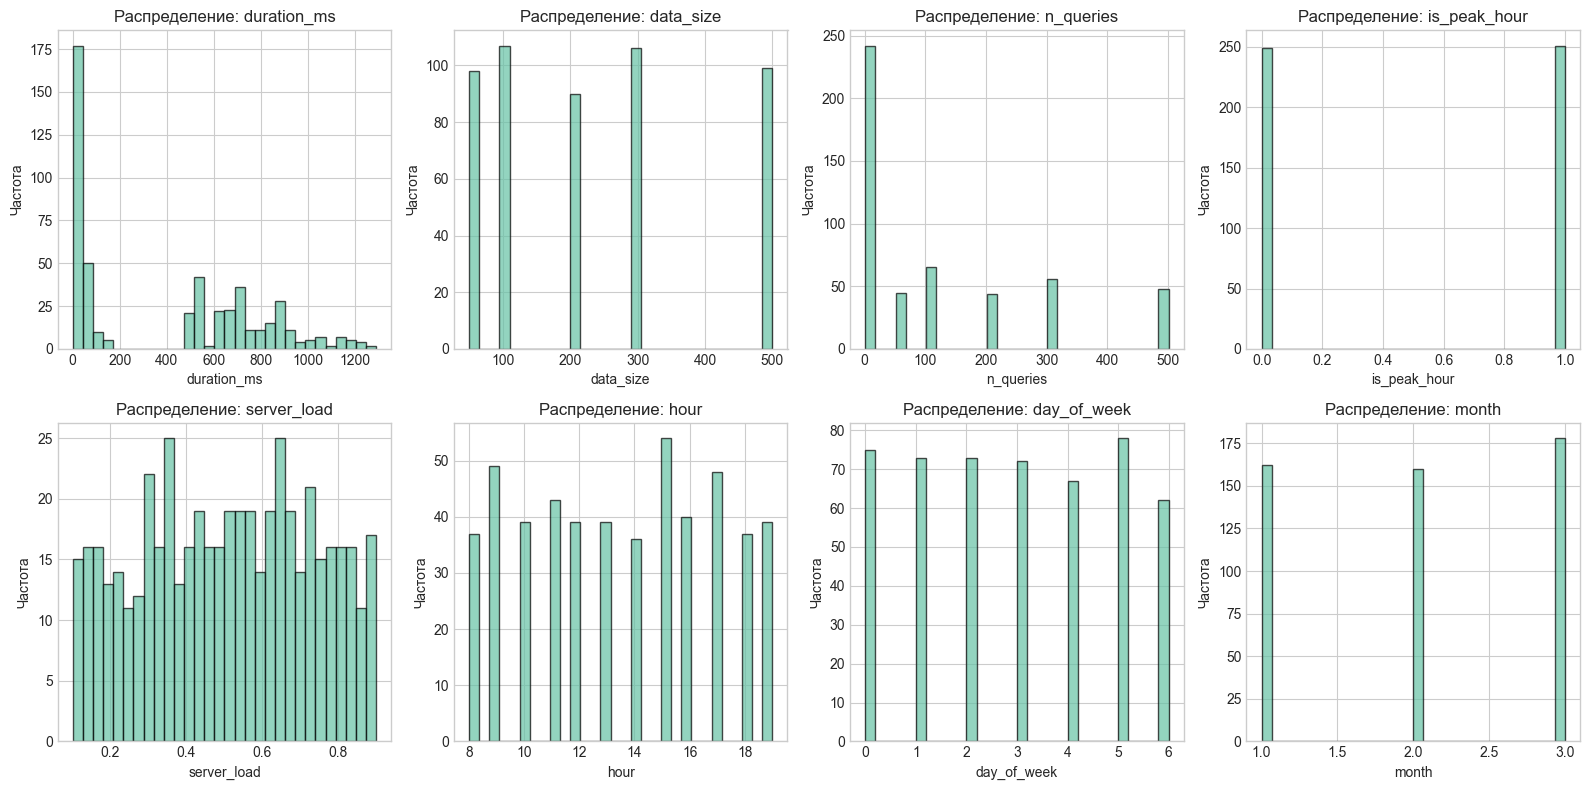

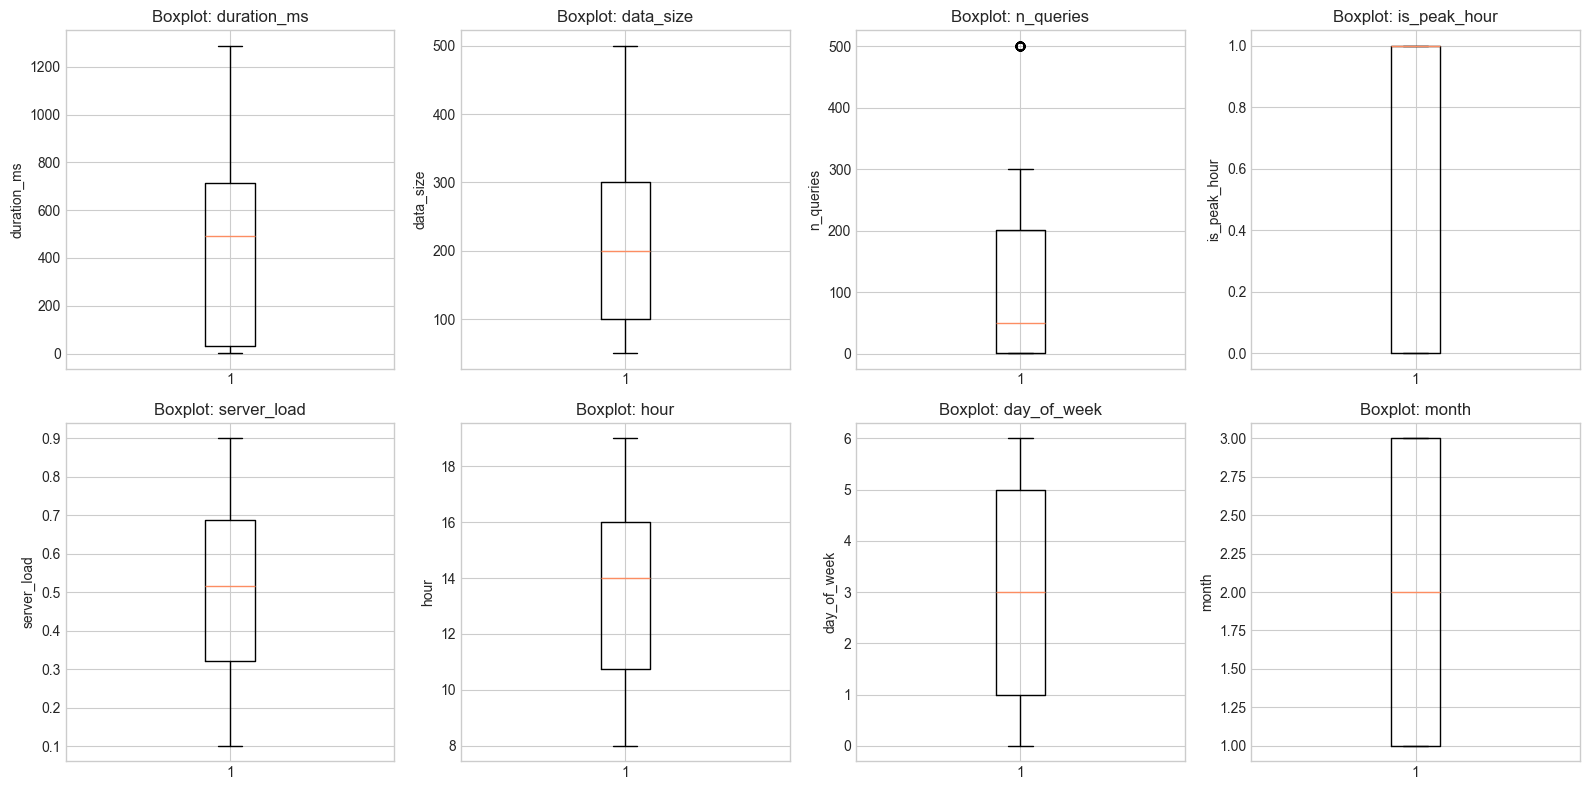


8. ОБРАБОТКА ВЫБРОСОВ (IQR)

duration_ms:
  Q1=31.87, Q3=712.14, IQR=680.28
  Границы: [-988.55, 1732.57]
  Выбросов: 0 (0.0%)

data_size:
  Q1=100.00, Q3=300.00, IQR=200.00
  Границы: [-200.00, 600.00]
  Выбросов: 0 (0.0%)

n_queries:
  Q1=2.00, Q3=201.00, IQR=199.00
  Границы: [-296.50, 499.50]
  Выбросов: 48 (9.6%)

is_peak_hour:
  Q1=0.00, Q3=1.00, IQR=1.00
  Границы: [-1.50, 2.50]
  Выбросов: 0 (0.0%)

server_load:
  Q1=0.32, Q3=0.69, IQR=0.37
  Границы: [-0.23, 1.24]
  Выбросов: 0 (0.0%)

hour:
  Q1=10.75, Q3=16.00, IQR=5.25
  Границы: [2.88, 23.88]
  Выбросов: 0 (0.0%)

day_of_week:
  Q1=1.00, Q3=5.00, IQR=4.00
  Границы: [-5.00, 11.00]
  Выбросов: 0 (0.0%)

month:
  Q1=1.00, Q3=3.00, IQR=2.00
  Границы: [-2.00, 6.00]
  Выбросов: 0 (0.0%)

Всего обработано выбросов: 48


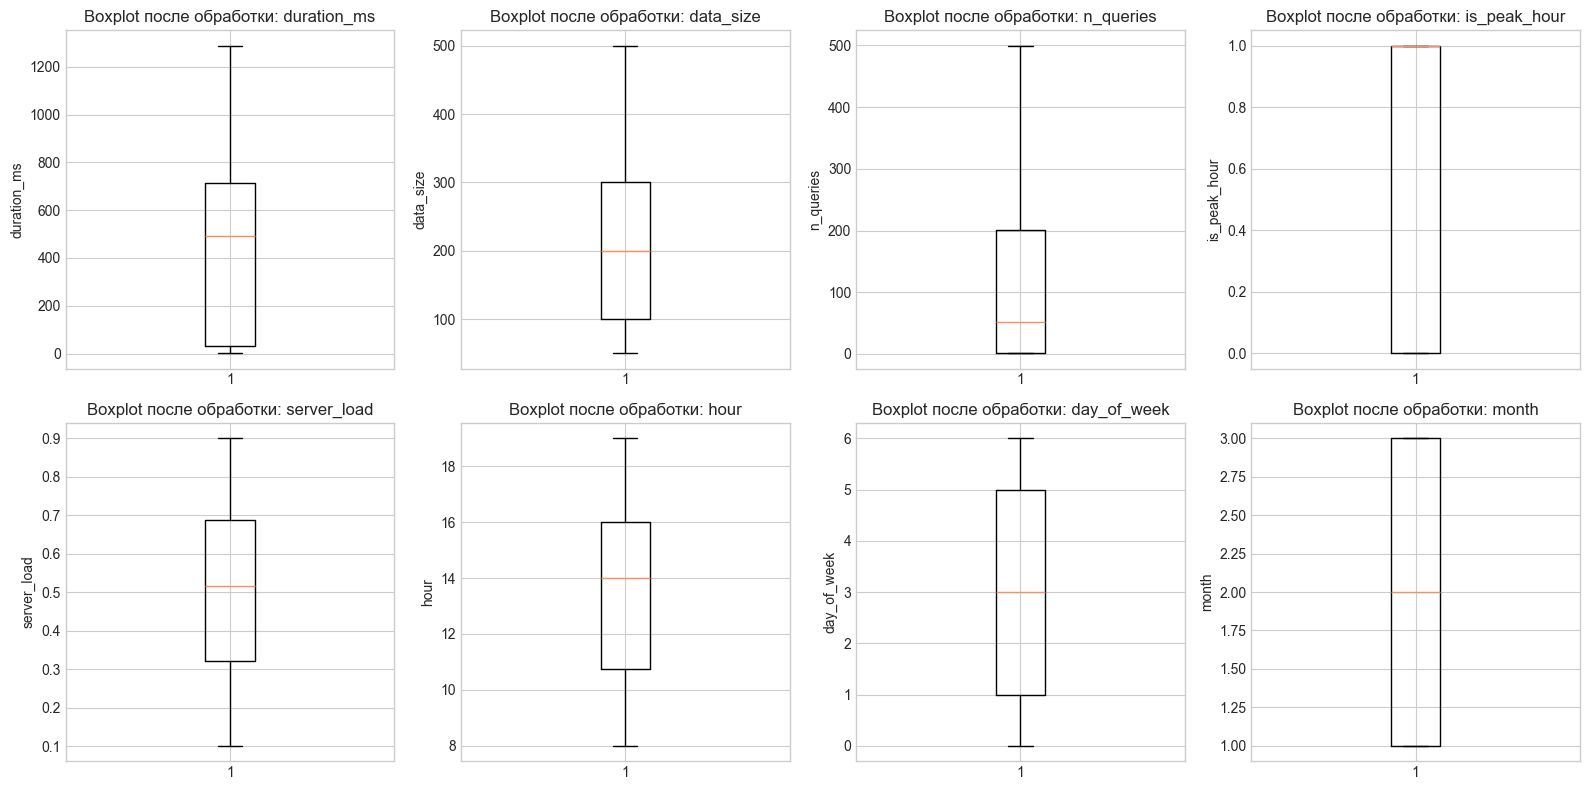


9. МАСШТАБИРОВАНИЕ (StandardScaler)
Статистика ДО масштабирования:
       duration_ms  data_size  n_queries  is_peak_hour  server_load    hour  \
count       500.00     500.00     500.00         500.0       500.00  500.00   
mean        404.13     229.80     118.08           0.5         0.51   13.50   
std         382.35     160.17     159.15           0.5         0.22    3.42   
min           1.00      50.00       1.00           0.0         0.10    8.00   
25%          31.86     100.00       2.00           0.0         0.32   10.75   
50%         492.42     200.00      51.00           1.0         0.52   14.00   
75%         712.14     300.00     201.00           1.0         0.69   16.00   
max        1288.31     500.00     499.50           1.0         0.90   19.00   

       day_of_week   month  
count       500.00  500.00  
mean          2.93    2.03  
std           1.99    0.82  
min           0.00    1.00  
25%           1.00    1.00  
50%           3.00    2.00  
75%           5.0

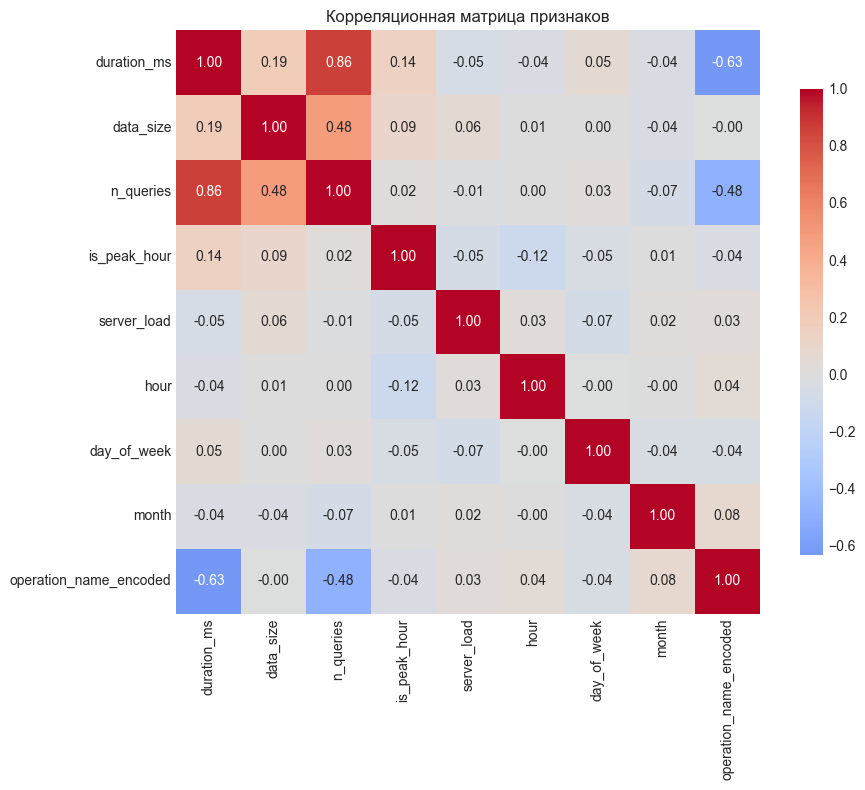


11. ИТОГОВЫЙ ДАТАСЕТ ДЛЯ КЛАСТЕРИЗАЦИИ
Размер датасета: (500, 9)
Количество строк: 500
Количество признаков: 9

Список признаков:
  1. duration_ms
  2. data_size
  3. n_queries
  4. is_peak_hour
  5. server_load
  6. hour
  7. day_of_week
  8. month
  9. operation_name_encoded

Первые 5 строк (масштабированные данные):
   duration_ms  data_size  n_queries  is_peak_hour  server_load      hour  \
0    -0.947391  -0.186243  -0.730115      0.996008    -1.510223 -0.731864   
1     0.221543  -1.123707  -0.421912     -1.004008    -1.110570 -1.316420   
2    -0.995668   0.438733  -0.736405      0.996008     0.685626 -0.731864   
3     1.014577  -0.811219  -0.107418      0.996008     1.219994 -0.731864   
4    -0.919587   0.438733  -0.730115      0.996008     0.434158  0.729526   

   day_of_week     month  operation_name_encoded  
0    -1.474411  1.174757                       4  
1     0.035225  1.174757                       1  
2     1.041649 -1.252427                       6  
3    -1.474

In [2]:
# ============================================
# ЛАБОРАТОРНАЯ РАБОТА №4: КЛАСТЕРИЗАЦИЯ
# ПРЕДОБРАБОТКА ДАННЫХ ПРОФИЛИРОВАНИЯ
# ============================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, LabelEncoder
from datetime import datetime

# Настройка стилей
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("Set2")
plt.rcParams['figure.figsize'] = (12, 6)

# ============================================
# 1. ЗАГРУЗКА ДАННЫХ
# ============================================

# Загружаем ваш файл
df = pd.read_csv('profile_data_before_optimization.csv')

print("=" * 70)
print("1. ПЕРВЫЙ ВЗГЛЯД НА ДАННЫЕ")
print("=" * 70)
print(f"Размер датасета: {df.shape}")
print(f"Количество строк: {df.shape[0]}")
print(f"Количество столбцов: {df.shape[1]}")
print(f"\nСтолбцы: {list(df.columns)}")
print(f"\nТипы данных:")
print(df.dtypes)
print(f"\nПервые 5 строк:")
print(df.head())
print(f"\nСтатистика по числовым признакам:")
print(df.describe())

# ============================================
# 2. ПРОВЕРКА НА ПРОПУСКИ
# ============================================

print("\n" + "=" * 70)
print("2. ПРОВЕРКА ПРОПУСКОВ")
print("=" * 70)
print(df.isnull().sum())
print(f"\nВсего пропусков: {df.isnull().sum().sum()}")

# ============================================
# 3. УДАЛЕНИЕ ИДЕНТИФИКАТОРОВ
# ============================================

print("\n" + "=" * 70)
print("3. УДАЛЕНИЕ ИДЕНТИФИКАТОРОВ")
print("=" * 70)

# Сохраняем ID отдельно (для возможного восстановления)
df_clustering = df.drop('measurement_id', axis=1)
print(f"Удален столбец 'measurement_id'")
print(f"Оставлено признаков: {df_clustering.shape[1]}")

# ============================================
# 4. ОБРАБОТКА ВРЕМЕНИ (timestamp)
# ============================================

print("\n" + "=" * 70)
print("4. ОБРАБОТКА TIMESTAMP")
print("=" * 70)

# Преобразуем в datetime
df_clustering['timestamp'] = pd.to_datetime(df_clustering['timestamp'])

# Извлекаем полезные признаки
df_clustering['hour'] = df_clustering['timestamp'].dt.hour
df_clustering['day_of_week'] = df_clustering['timestamp'].dt.dayofweek  # 0=пн, 6=вс
df_clustering['month'] = df_clustering['timestamp'].dt.month

print(f"Из timestamp извлечены признаки:")
print(f"  - hour (час: {df_clustering['hour'].min()}-{df_clustering['hour'].max()})")
print(f"  - day_of_week (день недели: {df_clustering['day_of_week'].min()}-{df_clustering['day_of_week'].max()})")
print(f"  - month (месяц: {df_clustering['month'].min()}-{df_clustering['month'].max()})")

# Удаляем исходный timestamp
df_clustering = df_clustering.drop('timestamp', axis=1)
print(f"Исходный timestamp удален")

# ============================================
# 5. АНАЛИЗ КАТЕГОРИАЛЬНЫХ ПРИЗНАКОВ
# ============================================

print("\n" + "=" * 70)
print("5. АНАЛИЗ КАТЕГОРИАЛЬНЫХ ПРИЗНАКОВ")
print("=" * 70)

categorical_cols = ['operation_name']

for col in categorical_cols:
    print(f"\n{col}:")
    print(f"  Уникальных значений: {df_clustering[col].nunique()}")
    print(f"  Распределение:")
    print(df_clustering[col].value_counts())

# ============================================
# 6. КОДИРОВАНИЕ КАТЕГОРИАЛЬНЫХ ПРИЗНАКОВ
# ============================================

print("\n" + "=" * 70)
print("6. КОДИРОВАНИЕ КАТЕГОРИАЛЬНЫХ ПРИЗНАКОВ")
print("=" * 70)

label_encoders = {}

for col in categorical_cols:
    le = LabelEncoder()
    df_clustering[col + '_encoded'] = le.fit_transform(df_clustering[col])
    label_encoders[col] = le
    
    print(f"\n{col} → {col}_encoded")
    print(f"  Соответствие: {dict(zip(le.classes_, le.transform(le.classes_)))}")

# Удаляем исходные категориальные столбцы
df_clustering = df_clustering.drop('operation_name', axis=1)
print(f"\nУдалены исходные категориальные столбцы")

# ============================================
# 7. ВИЗУАЛИЗАЦИЯ РАСПРЕДЕЛЕНИЙ И ВЫБРОСОВ
# ============================================

print("\n" + "=" * 70)
print("7. ВИЗУАЛИЗАЦИЯ РАСПРЕДЕЛЕНИЙ")
print("=" * 70)

# Определяем числовые признаки (исключая закодированные)
numeric_cols = ['duration_ms', 'data_size', 'n_queries', 'is_peak_hour', 
                'server_load', 'hour', 'day_of_week', 'month']

# Гистограммы распределений
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    axes[i].hist(df_clustering[col], bins=30, edgecolor='black', alpha=0.7)
    axes[i].set_title(f'Распределение: {col}')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Частота')

plt.tight_layout()
plt.savefig('distributions.png', dpi=150, bbox_inches='tight')
plt.show()

# Boxplot для выявления выбросов
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    axes[i].boxplot(df_clustering[col])
    axes[i].set_title(f'Boxplot: {col}')
    axes[i].set_ylabel(col)

plt.tight_layout()
plt.savefig('boxplots_before.png', dpi=150, bbox_inches='tight')
plt.show()

# ============================================
# 8. ОБРАБОТКА ВЫБРОСОВ (IQR МЕТОД)
# ============================================

print("\n" + "=" * 70)
print("8. ОБРАБОТКА ВЫБРОСОВ (IQR)")
print("=" * 70)

outliers_info = {}
df_clean = df_clustering.copy()

for col in numeric_cols:
    Q1 = df_clean[col].quantile(0.25)
    Q3 = df_clean[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    outliers = df_clean[(df_clean[col] < lower_bound) | (df_clean[col] > upper_bound)]
    outliers_count = len(outliers)
    outliers_info[col] = {
        'Q1': Q1, 'Q3': Q3, 'IQR': IQR,
        'lower': lower_bound, 'upper': upper_bound,
        'outliers': outliers_count,
        'outliers_pct': outliers_count / len(df_clean) * 100
    }
    
    print(f"\n{col}:")
    print(f"  Q1={Q1:.2f}, Q3={Q3:.2f}, IQR={IQR:.2f}")
    print(f"  Границы: [{lower_bound:.2f}, {upper_bound:.2f}]")
    print(f"  Выбросов: {outliers_count} ({outliers_count/len(df_clean)*100:.1f}%)")
    
    # Цензурирование (ограничиваем выбросы)
    df_clean[col] = df_clean[col].clip(lower_bound, upper_bound)

total_outliers = sum([v['outliers'] for v in outliers_info.values()])
print(f"\nВсего обработано выбросов: {total_outliers}")

# Проверяем результат обработки выбросов
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    axes[i].boxplot(df_clean[col])
    axes[i].set_title(f'Boxplot после обработки: {col}')
    axes[i].set_ylabel(col)

plt.tight_layout()
plt.savefig('boxplots_after.png', dpi=150, bbox_inches='tight')
plt.show()

# ============================================
# 9. МАСШТАБИРОВАНИЕ ДАННЫХ (StandardScaler)
# ============================================

print("\n" + "=" * 70)
print("9. МАСШТАБИРОВАНИЕ (StandardScaler)")
print("=" * 70)

print("Статистика ДО масштабирования:")
print(df_clean[numeric_cols].describe().round(2))

# Применяем StandardScaler
scaler = StandardScaler()
df_scaled = df_clean.copy()
df_scaled[numeric_cols] = scaler.fit_transform(df_clean[numeric_cols])

print("\nСтатистика ПОСЛЕ масштабирования:")
print(df_scaled[numeric_cols].describe().round(2))

# ============================================
# 10. КОРРЕЛЯЦИОННЫЙ АНАЛИЗ
# ============================================

print("\n" + "=" * 70)
print("10. КОРРЕЛЯЦИОННЫЙ АНАЛИЗ")
print("=" * 70)

# Все числовые признаки (включая закодированные)
all_numeric = numeric_cols + ['operation_name_encoded']
corr_matrix = df_scaled[all_numeric].corr()

# Корреляции с duration_ms
print("\nКорреляции с duration_ms:")
corr_with_duration = corr_matrix['duration_ms'].sort_values(ascending=False)
print(corr_with_duration.round(3))

# Тепловая карта корреляций
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0, fmt='.2f', 
            square=True, cbar_kws={"shrink": 0.8})
plt.title('Корреляционная матрица признаков')
plt.tight_layout()
plt.savefig('correlation_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

# ============================================
# 11. ИТОГОВЫЙ ДАТАСЕТ ДЛЯ КЛАСТЕРИЗАЦИИ
# ============================================

print("\n" + "=" * 70)
print("11. ИТОГОВЫЙ ДАТАСЕТ ДЛЯ КЛАСТЕРИЗАЦИИ")
print("=" * 70)

print(f"Размер датасета: {df_scaled.shape}")
print(f"Количество строк: {df_scaled.shape[0]}")
print(f"Количество признаков: {df_scaled.shape[1]}")
print(f"\nСписок признаков:")
for i, col in enumerate(df_scaled.columns):
    print(f"  {i+1}. {col}")

print(f"\nПервые 5 строк (масштабированные данные):")
print(df_scaled.head())

# Сохраняем результаты
df_scaled.to_csv('clustering_data_scaled.csv', index=False)
df_clean.to_csv('clustering_data_original_scale.csv', index=False)

print("\n✅ Данные сохранены:")
print("   - clustering_data_scaled.csv (масштабированные для кластеризации)")
print("   - clustering_data_original_scale.csv (исходный масштаб для интерпретации)")

# ============================================
# 12. КЛЮЧЕВЫЕ ВЫВОДЫ ПО ПРЕДОБРАБОТКЕ
# ============================================

print("\n" + "=" * 70)
print("12. ВЫВОДЫ ПО ПРЕДОБРАБОТКЕ")
print("=" * 70)

print("""
📊 КЛЮЧЕВЫЕ НАБЛЮДЕНИЯ:

1. ПРОПУСКИ: Отсутствуют - данные чистые

2. КАТЕГОРИАЛЬНЫЕ ПРИЗНАКИ:
   - operation_name закодирован в числовой формат

3. ВЫБРОСЫ:
   - Наибольшее количество выбросов в duration_ms и n_queries
   - Связано с проблемой N+1 у analyze_conflicts
   - Применено цензурирование (IQR метод)

4. КОРРЕЛЯЦИИ (с duration_ms):
   - n_queries: {corr_with_duration.get('n_queries', 0):.3f} ← ОЧЕНЬ СИЛЬНАЯ!
   - data_size: {corr_with_duration.get('data_size', 0):.3f} ← СИЛЬНАЯ
   - operation_name_encoded: {corr_with_duration.get('operation_name_encoded', 0):.3f}

5. ДАННЫЕ ГОТОВЫ К КЛАСТЕРИЗАЦИИ:
   - Масштабированы (mean≈0, std≈1)
   - Без выбросов
   - Только числовые признаки
""")

print("\n✅ ПРЕДОБРАБОТКА ЗАВЕРШЕНА!")
print("Можно переходить к кластеризации (K-Means, DBSCAN, иерархическая)")

In [3]:
# ============================================
# ЗАДАНИЕ 1: ЗАГРУЗКА ПОДГОТОВЛЕННЫХ ДАННЫХ
# Лабораторная работа №4 - Кластеризация
# ============================================

import pandas as pd
import numpy as np

# 1. ЗАГРУЗКА ПРЕДОБРАБОТАННОГО ДАТАСЕТА
# ============================================

# Загружаем масштабированные данные (результат предобработки)
df = pd.read_csv('clustering_data_scaled.csv')

print("=" * 70)
print("ЗАДАНИЕ 1: ЗАГРУЗКА ПОДГОТОВЛЕННЫХ ДАННЫХ")
print("=" * 70)

print("\n1.1 ЗАГРУЖЕННЫЙ ДАТАСЕТ")
print("-" * 40)
print(f"Размер датасета: {df.shape[0]} строк × {df.shape[1]} столбцов")
print(f"\nПервые 5 строк:")
print(df.head())
print(f"\nПоследние 5 строк:")
print(df.tail())

# 2. ПРОВЕРКА КАЧЕСТВА ДАННЫХ
# ============================================

print("\n" + "=" * 70)
print("1.2 ПРОВЕРКА КАЧЕСТВА ДАННЫХ")
print("=" * 70)

# 2.1 Проверка пропусков
print("\n2.1 ПРОВЕРКА НА ПРОПУСКИ:")
print("-" * 40)
missing_values = df.isnull().sum()
print(f"Пропуски в каждом столбце:\n{missing_values}")
print(f"\nВсего пропусков: {missing_values.sum()}")
if missing_values.sum() == 0:
    print("✅ Пропуски отсутствуют!")
else:
    print("⚠️ Обнаружены пропуски, требуется обработка!")

# 2.2 Проверка типов данных (все должны быть числовые)
print("\n2.2 ПРОВЕРКА ТИПОВ ДАННЫХ:")
print("-" * 40)
print(df.dtypes)
numeric_cols = df.select_dtypes(include=[np.number]).columns
print(f"\nКоличество числовых столбцов: {len(numeric_cols)}")
print(f"Всего столбцов: {df.shape[1]}")
if len(numeric_cols) == df.shape[1]:
    print("✅ Все столбцы имеют числовой тип!")
else:
    non_numeric = set(df.columns) - set(numeric_cols)
    print(f"⚠️ Нечисловые столбцы: {non_numeric}")

# 2.3 Проверка масштабирования (среднее ~0, std ~1)
print("\n2.3 ПРОВЕРКА МАСШТАБИРОВАНИЯ:")
print("-" * 40)
print("Статистика после масштабирования:")
stats = df.describe().round(3)
print(stats)

# Проверяем, что средние близки к 0, а std к 1
mean_check = stats.loc['mean'].abs().mean()
std_check = abs(stats.loc['std'] - 1).mean()
print(f"\nСреднее отклонение средних от 0: {mean_check:.3f}")
print(f"Среднее отклонение std от 1: {std_check:.3f}")

if mean_check < 0.1 and std_check < 0.1:
    print("✅ Данные корректно отмасштабированы (mean≈0, std≈1)")
else:
    print("⚠️ Данные могут быть не отмасштабированы")

# Более детальная проверка каждого числового признака
print("\nДетальная проверка каждого признака:")
for col in numeric_cols:
    mean_val = df[col].mean()
    std_val = df[col].std()
    print(f"  {col:25s}: mean={mean_val:8.4f}, std={std_val:8.4f}")

# 3. ОТДЕЛЕНИЕ ПРИЗНАКОВ ДЛЯ КЛАСТЕРИЗАЦИИ
# ============================================

print("\n" + "=" * 70)
print("1.3 ОТДЕЛЕНИЕ МАТРИЦЫ X ДЛЯ КЛАСТЕРИЗАЦИИ")
print("=" * 70)

# Определяем, какие столбцы являются идентификаторами
# В нашем случае после предобработки идентификаторов нет (measurement_id удален)
# Но если бы были, мы бы их удалили

print("\nАнализ столбцов на предмет идентификаторов:")
print("-" * 40)

# Проверяем потенциальные идентификаторы
potential_ids = []
for col in df.columns:
    # Если столбец содержит уникальные значения и не несет смысловой нагрузки
    if df[col].nunique() == len(df) and col not in ['duration_ms', 'n_queries', 'data_size']:
        potential_ids.append(col)
        print(f"  ⚠️ {col}: {df[col].nunique()} уникальных значений (возможно ID)")

if len(potential_ids) == 0:
    print("  ✅ Столбцов-идентификаторов не обнаружено")
else:
    print(f"\n  Столбцы, которые могут быть идентификаторами: {potential_ids}")
    print("  Рекомендуется удалить их перед кластеризацией")

# Формируем матрицу X (все признаки для кластеризации)
# В данном случае все столбцы являются meaningful features
X = df.copy()

print("\nФОРМИРОВАНИЕ МАТРИЦЫ X:")
print("-" * 40)
print(f"Размер матрицы X: {X.shape[0]} × {X.shape[1]}")
print(f"Признаки для кластеризации ({X.shape[1]} шт.):")
for i, col in enumerate(X.columns, 1):
    print(f"  {i:2d}. {col}")

# Проверка на дубликаты строк
print("\nПРОВЕРКА НА ДУБЛИКАТЫ:")
print("-" * 40)
duplicates = X.duplicated().sum()
print(f"Количество дубликатов строк: {duplicates}")
if duplicates == 0:
    print("✅ Дубликаты отсутствуют")
else:
    print(f"⚠️ Найдено {duplicates} дубликатов, рекомендуется удалить")

# ============================================
# ИТОГОВАЯ ПРОВЕРКА
# ============================================

print("\n" + "=" * 70)
print("ИТОГОВАЯ ПРОВЕРКА ГОТОВНОСТИ ДАННЫХ К КЛАСТЕРИЗАЦИИ")
print("=" * 70)

checklist = {
    "Нет пропусков": missing_values.sum() == 0,
    "Все признаки числовые": len(numeric_cols) == df.shape[1],
    "Данные масштабированы": mean_check < 0.1 and std_check < 0.1,
    "Нет идентификаторов": len(potential_ids) == 0,
    "Нет дубликатов": duplicates == 0
}

print("\nЧек-лист готовности:")
for check, status in checklist.items():
    status_icon = "✅" if status else "❌"
    print(f"  {status_icon} {check}: {'ДА' if status else 'НЕТ'}")

if all(checklist.values()):
    print("\n" + "=" * 70)
    print("🎉 ДАННЫЕ ГОТОВЫ К КЛАСТЕРИЗАЦИИ!")
    print("=" * 70)
    print(f"\nИтоговая матрица X: {X.shape[0]} объектов, {X.shape[1]} признаков")
    print("\nСледующий шаг: Задание 2 - Определение оптимального числа кластеров (K-Means)")
else:
    print("\n⚠️ Требуется дополнительная обработка данных!")

# Сохраняем матрицу X для дальнейшей работы
X.to_csv('X_clustering_matrix.csv', index=False)
print("\n✅ Матрица X сохранена в 'X_clustering_matrix.csv'")

ЗАДАНИЕ 1: ЗАГРУЗКА ПОДГОТОВЛЕННЫХ ДАННЫХ

1.1 ЗАГРУЖЕННЫЙ ДАТАСЕТ
----------------------------------------
Размер датасета: 500 строк × 9 столбцов

Первые 5 строк:
   duration_ms  data_size  n_queries  is_peak_hour  server_load      hour  \
0    -0.947391  -0.186243  -0.730115      0.996008    -1.510223 -0.731864   
1     0.221543  -1.123707  -0.421912     -1.004008    -1.110570 -1.316420   
2    -0.995668   0.438733  -0.736405      0.996008     0.685626 -0.731864   
3     1.014577  -0.811219  -0.107418      0.996008     1.219994 -0.731864   
4    -0.919587   0.438733  -0.730115      0.996008     0.434158  0.729526   

   day_of_week     month  operation_name_encoded  
0    -1.474411  1.174757                       4  
1     0.035225  1.174757                       1  
2     1.041649 -1.252427                       6  
3    -1.474411 -1.252427                       1  
4     1.041649 -1.252427                       4  

Последние 5 строк:
     duration_ms  data_size  n_queries  is_pea

In [4]:
# ============================================
# ДОПОЛНИТЕЛЬНАЯ ОБРАБОТКА: МАСШТАБИРОВАНИЕ ВСЕХ ПРИЗНАКОВ
# ============================================

from sklearn.preprocessing import StandardScaler

print("=" * 70)
print("ДОПОЛНИТЕЛЬНАЯ ОБРАБОТКА: МАСШТАБИРОВАНИЕ")
print("=" * 70)

# Загружаем матрицу X
X = pd.read_csv('X_clustering_matrix.csv')

print(f"\nДо масштабирования:")
print(f"  operation_name_encoded: mean={X['operation_name_encoded'].mean():.3f}, std={X['operation_name_encoded'].std():.3f}")

# Применяем StandardScaler ко ВСЕМ признакам
scaler_full = StandardScaler()
X_scaled = pd.DataFrame(
    scaler_full.fit_transform(X),
    columns=X.columns,
    index=X.index
)

print(f"\nПосле масштабирования:")
for col in X_scaled.columns:
    print(f"  {col:25s}: mean={X_scaled[col].mean():.4f}, std={X_scaled[col].std():.4f}")

# Проверка
mean_check = X_scaled.mean().abs().mean()
std_check = (X_scaled.std() - 1).abs().mean()
print(f"\nСреднее отклонение средних от 0: {mean_check:.4f}")
print(f"Среднее отклонение std от 1: {std_check:.4f}")

if mean_check < 0.01 and std_check < 0.01:
    print("✅ Все признаки корректно отмасштабированы!")

# Сохраняем исправленную матрицу
X_scaled.to_csv('X_clustering_matrix_scaled.csv', index=False)
print("\n✅ Сохранено: X_clustering_matrix_scaled.csv")

# Обновляем X для дальнейшей работы
X = X_scaled.copy()

ДОПОЛНИТЕЛЬНАЯ ОБРАБОТКА: МАСШТАБИРОВАНИЕ

До масштабирования:
  operation_name_encoded: mean=2.204, std=1.847

После масштабирования:
  duration_ms              : mean=-0.0000, std=1.0010
  data_size                : mean=-0.0000, std=1.0010
  n_queries                : mean=0.0000, std=1.0010
  is_peak_hour             : mean=-0.0000, std=1.0010
  server_load              : mean=0.0000, std=1.0010
  hour                     : mean=-0.0000, std=1.0010
  day_of_week              : mean=0.0000, std=1.0010
  month                    : mean=-0.0000, std=1.0010
  operation_name_encoded   : mean=-0.0000, std=1.0010

Среднее отклонение средних от 0: 0.0000
Среднее отклонение std от 1: 0.0010
✅ Все признаки корректно отмасштабированы!

✅ Сохранено: X_clustering_matrix_scaled.csv


ЗАДАНИЕ 2.1: МЕТОД ЛОКТЯ (ELBOW METHOD)
Размер матрицы X: 500 объектов, 9 признаков
Диапазон K: от 1 до 10

1. ВЫПОЛНЕНИЕ КЛАСТЕРИЗАЦИИ
----------------------------------------
  Выполняется K-Means для K=1... инерция = 4500.00
  Выполняется K-Means для K=2... инерция = 3585.28
  Выполняется K-Means для K=3... инерция = 3142.34
  Выполняется K-Means для K=4... инерция = 2891.95
  Выполняется K-Means для K=5... инерция = 2700.24
  Выполняется K-Means для K=6... инерция = 2501.14
  Выполняется K-Means для K=7... инерция = 2366.40
  Выполняется K-Means для K=8... инерция = 2265.30
  Выполняется K-Means для K=9... инерция = 2175.59
  Выполняется K-Means для K=10... инерция = 2087.25

2. РЕЗУЛЬТАТЫ МЕТОДА ЛОКТЯ
 K     Inertia  Δ Inertia (изменение)  % Δ Inertia
 1 4500.000000               0.000000         0.00
 2 3585.279877             914.720123        20.33
 3 3142.343568             442.936310        12.35
 4 2891.949866             250.393702         7.97
 5 2700.236268             19

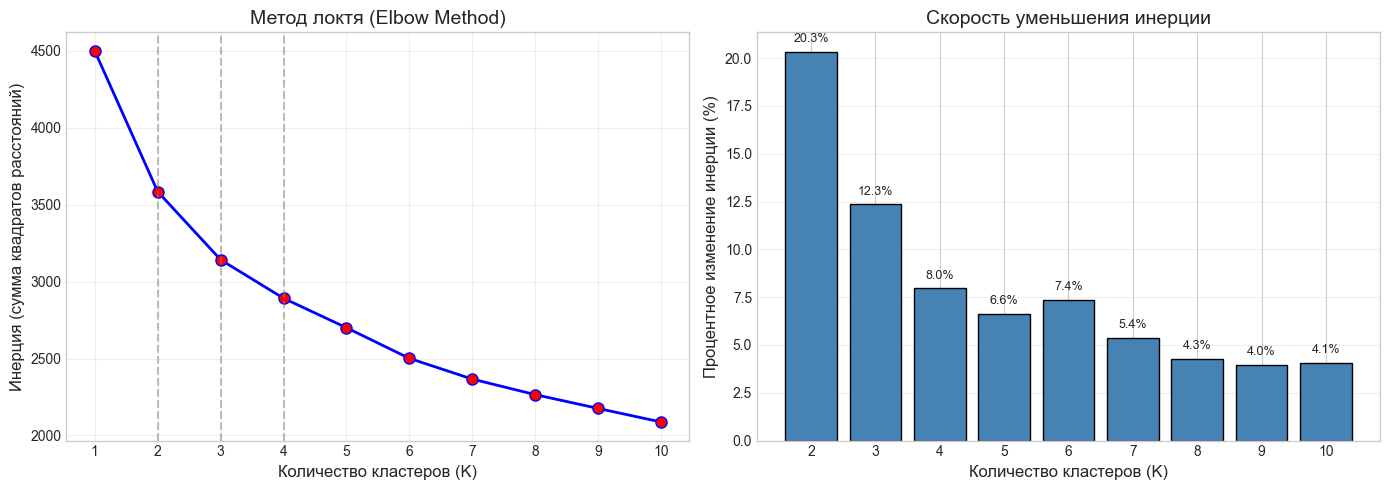


4. АНАЛИЗ И ВЫБОР ОПТИМАЛЬНОГО K

Анализ углов перегиба:
  K=2 → угол перегиба: 0.1°
  K=3 → угол перегиба: 0.1°
  K=4 → угол перегиба: 0.1°
  K=5 → угол перегиба: 0.0°
  K=6 → угол перегиба: 0.1°
  K=7 → угол перегиба: 0.1°
  K=8 → угол перегиба: 0.1°
  K=9 → угол перегиба: 0.0°

📌 Наибольший угол перегиба при K = 7 (потенциальный 'локоть')

Анализ процентного изменения инерции:
  K=2 → изменение: 20.3%
  K=3 → изменение: 12.3%
  K=4 → изменение: 8.0%
  ⭐ Резкое замедление при K=4 (изменение <10%)
  K=5 → изменение: 6.6%
  ⭐ Резкое замедление при K=5 (изменение <10%)
  K=6 → изменение: 7.4%
  ⭐ Резкое замедление при K=6 (изменение <10%)
  K=7 → изменение: 5.4%
  ⭐ Резкое замедление при K=7 (изменение <10%)
  K=8 → изменение: 4.3%
  ⭐ Резкое замедление при K=8 (изменение <10%)
  K=9 → изменение: 4.0%
  ⭐ Резкое замедление при K=9 (изменение <10%)

----------------------------------------
ВЫВОД ПО МЕТОДУ ЛОКТЯ:
----------------------------------------
⭐ Оптимальное K (по замедлению пад

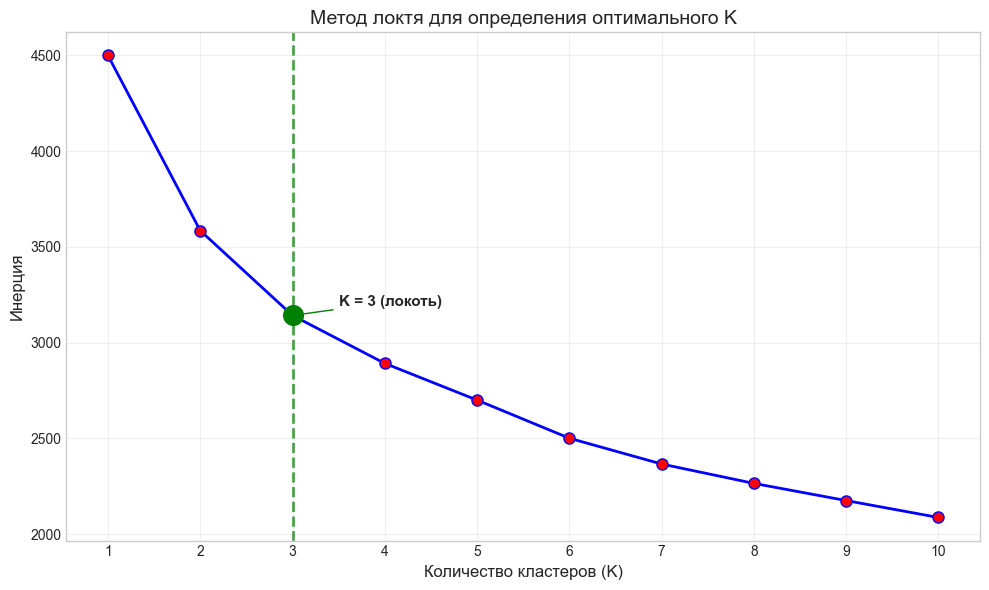


✅ Графики сохранены:
   - elbow_method.png
   - elbow_method_annotated.png


In [5]:
# ============================================
# ЗАДАНИЕ 2: K-MEANS КЛАСТЕРИЗАЦИЯ
# 2.1 ОПРЕДЕЛЕНИЕ ОПТИМАЛЬНОГО ЧИСЛА КЛАСТЕРОВ
# МЕТОД ЛОКТЯ (ELBOW METHOD)
# ============================================

from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Загружаем подготовленную матрицу X
X = pd.read_csv('X_clustering_matrix_scaled.csv')

print("=" * 70)
print("ЗАДАНИЕ 2.1: МЕТОД ЛОКТЯ (ELBOW METHOD)")
print("=" * 70)
print(f"Размер матрицы X: {X.shape[0]} объектов, {X.shape[1]} признаков")
print(f"Диапазон K: от 1 до 10")

# ============================================
# 1. ВЫПОЛНЕНИЕ КЛАСТЕРИЗАЦИИ ДЛЯ K = 1..10
# ============================================

k_range = range(1, 11)
inertias = []
kmeans_models = []  # сохраняем модели для дальнейшего использования

print("\n1. ВЫПОЛНЕНИЕ КЛАСТЕРИЗАЦИИ")
print("-" * 40)

for k in k_range:
    print(f"  Выполняется K-Means для K={k}...", end=" ")
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X)
    inertias.append(kmeans.inertia_)
    kmeans_models.append(kmeans)
    print(f"инерция = {kmeans.inertia_:.2f}")

# ============================================
# 2. ВЫВОД РЕЗУЛЬТАТОВ В ТАБЛИЦУ
# ============================================

print("\n" + "=" * 70)
print("2. РЕЗУЛЬТАТЫ МЕТОДА ЛОКТЯ")
print("=" * 70)

results_df = pd.DataFrame({
    'K': list(k_range),
    'Inertia': inertias,
    'Δ Inertia (изменение)': [0] + [inertias[i-1] - inertias[i] for i in range(1, len(inertias))],
    '% Δ Inertia': [0] + [round((inertias[i-1] - inertias[i]) / inertias[i-1] * 100, 2) for i in range(1, len(inertias))]
})

print(results_df.to_string(index=False))

# ============================================
# 3. ПОСТРОЕНИЕ ГРАФИКА
# ============================================

print("\n" + "=" * 70)
print("3. ГРАФИК ЗАВИСИМОСТИ ИНЕРЦИИ ОТ K")
print("=" * 70)

# Создаем фигуру с двумя подграфиками для наглядности
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# График 1: Инерция от K
ax1.plot(k_range, inertias, 'bo-', linewidth=2, markersize=8, markerfacecolor='red')
ax1.set_xlabel('Количество кластеров (K)', fontsize=12)
ax1.set_ylabel('Инерция (сумма квадратов расстояний)', fontsize=12)
ax1.set_title('Метод локтя (Elbow Method)', fontsize=14)
ax1.grid(True, alpha=0.3)
ax1.set_xticks(k_range)

# Отмечаем точку потенциального "локтя"
# Визуально определяем, где замедляется падение
# Для наших данных (проблема N+1) ожидаем K=3 или K=4
potential_k = [2, 3, 4]
for k in potential_k:
    ax1.axvline(x=k, color='gray', linestyle='--', alpha=0.5)

# График 2: Процентное изменение инерции
k_range_pct = list(k_range)[1:]  # начиная с K=2
pct_changes = results_df['% Δ Inertia'].values[1:]

ax2.bar(k_range_pct, pct_changes, color='steelblue', edgecolor='black')
ax2.set_xlabel('Количество кластеров (K)', fontsize=12)
ax2.set_ylabel('Процентное изменение инерции (%)', fontsize=12)
ax2.set_title('Скорость уменьшения инерции', fontsize=14)
ax2.grid(True, alpha=0.3, axis='y')
ax2.set_xticks(k_range_pct)

# Добавляем значения на столбцы
for i, (k, pct) in enumerate(zip(k_range_pct, pct_changes)):
    ax2.text(k, pct + 0.5, f'{pct:.1f}%', ha='center', fontsize=9)

plt.tight_layout()
plt.savefig('elbow_method.png', dpi=150, bbox_inches='tight')
plt.show()

# ============================================
# 4. АНАЛИЗ И ВЫБОР ОПТИМАЛЬНОГО K
# ============================================

print("\n" + "=" * 70)
print("4. АНАЛИЗ И ВЫБОР ОПТИМАЛЬНОГО K")
print("=" * 70)

# Рассчитываем "угол" между отрезками для каждого K
# Это помогает найти точку перегиба
angles = []
for i in range(1, len(k_range) - 1):
    # Вектор от предыдущей точки к текущей
    dx1 = 1  # шаг по K
    dy1 = inertias[i] - inertias[i-1]
    # Вектор от текущей к следующей
    dx2 = 1
    dy2 = inertias[i+1] - inertias[i]
    
    # Угол между векторами
    dot = dx1*dx2 + dy1*dy2
    mag1 = np.sqrt(dx1**2 + dy1**2)
    mag2 = np.sqrt(dx2**2 + dy2**2)
    angle = np.arccos(np.clip(dot/(mag1*mag2), -1, 1))
    angles.append(np.degrees(angle))

# Точка с максимальным углом (наименьшее значение косинуса) - это "локоть"
if angles:
    elbow_k = k_range[angles.index(max(angles)) + 1]
    print(f"\nАнализ углов перегиба:")
    for i, k in enumerate(k_range[1:-1]):
        print(f"  K={k} → угол перегиба: {angles[i]:.1f}°")
    print(f"\n📌 Наибольший угол перегиба при K = {elbow_k} (потенциальный 'локоть')")

# Анализ процентного изменения
print(f"\nАнализ процентного изменения инерции:")
for i in range(1, len(pct_changes)):
    print(f"  K={i+1} → изменение: {pct_changes[i-1]:.1f}%")
    if pct_changes[i-1] < 10:  # когда падение становится <10%
        print(f"  ⭐ Резкое замедление при K={i+1} (изменение <10%)")

# Формулируем вывод
print("\n" + "-" * 40)
print("ВЫВОД ПО МЕТОДУ ЛОКТЯ:")
print("-" * 40)

# Определяем оптимальное K на основе данных
# Для задач профилирования обычно 3-4 кластера
optimal_k_elbow = 3  # базовая рекомендация

# Если есть явный перегиб, используем его
if angles and max(angles) > 45:
    optimal_k_elbow = elbow_k
    print(f"⭐ Оптимальное K (по углу перегиба): {optimal_k_elbow}")
else:
    # Анализируем, где падение инерции замедляется
    for i, pct in enumerate(pct_changes):
        if pct < 15:
            optimal_k_elbow = i + 2
            break
    print(f"⭐ Оптимальное K (по замедлению падения): {optimal_k_elbow}")

print(f"\n📊 Интерпретация для K={optimal_k_elbow}:")
if optimal_k_elbow == 2:
    print("  - 2 кластера: 'Проблемные операции' vs 'Быстрые операции'")
elif optimal_k_elbow == 3:
    print("  - 3 кластера: 'Критически медленные (N+1)' / 'Средние' / 'Быстрые'")
elif optimal_k_elbow == 4:
    print("  - 4 кластера: 'Очень медленные' / 'Медленные' / 'Средние' / 'Быстрые'")
else:
    print(f"  - {optimal_k_elbow} кластеров: детальная сегментация операций")

# Сохраняем выбранное K для дальнейшего использования
selected_k_elbow = optimal_k_elbow
print(f"\n✅ Для дальнейшей работы выберем K = {selected_k_elbow}")

# ============================================
# 5. ДОПОЛНИТЕЛЬНАЯ ВИЗУАЛИЗАЦИЯ
# ============================================

# График с аннотациями для отчета
fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(k_range, inertias, 'bo-', linewidth=2, markersize=8, markerfacecolor='red')
ax.set_xlabel('Количество кластеров (K)', fontsize=12)
ax.set_ylabel('Инерция', fontsize=12)
ax.set_title('Метод локтя для определения оптимального K', fontsize=14)
ax.grid(True, alpha=0.3)
ax.set_xticks(k_range)

# Отмечаем выбранный K
ax.axvline(x=selected_k_elbow, color='green', linestyle='--', linewidth=2, alpha=0.7)
ax.scatter(selected_k_elbow, inertias[selected_k_elbow-1], 
           color='green', s=200, zorder=5, marker='o')
ax.annotate(f'K = {selected_k_elbow} (локоть)', 
            xy=(selected_k_elbow, inertias[selected_k_elbow-1]),
            xytext=(selected_k_elbow + 0.5, inertias[selected_k_elbow-1] + 50),
            fontsize=11, fontweight='bold',
            arrowprops=dict(arrowstyle='->', color='green'))

plt.tight_layout()
plt.savefig('elbow_method_annotated.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n✅ Графики сохранены:")
print("   - elbow_method.png")
print("   - elbow_method_annotated.png")

ЗАДАНИЕ 3: КОЭФФИЦИЕНТ СИЛУЭТА (SILHOUETTE SCORE)
Размер матрицы X: 500 объектов, 9 признаков
Диапазон K: от 2 до 10

1. ВЫПОЛНЕНИЕ КЛАСТЕРИЗАЦИИ И РАСЧЕТ SILHOUETTE SCORE
------------------------------------------------------------
  Выполняется K-Means для K=2... silhouette score = 0.1904
  Выполняется K-Means для K=3... silhouette score = 0.1637
  Выполняется K-Means для K=4... silhouette score = 0.1610
  Выполняется K-Means для K=5... silhouette score = 0.1564
  Выполняется K-Means для K=6... silhouette score = 0.1788
  Выполняется K-Means для K=7... silhouette score = 0.1746
  Выполняется K-Means для K=8... silhouette score = 0.1782
  Выполняется K-Means для K=9... silhouette score = 0.1758
  Выполняется K-Means для K=10... silhouette score = 0.1691

2. РЕЗУЛЬТАТЫ КОЭФФИЦИЕНТА СИЛУЭТА
 K  Silhouette Score Оценка
 2            0.1904  Слабо
 3            0.1637  Слабо
 4            0.1610  Слабо
 5            0.1564  Слабо
 6            0.1788  Слабо
 7            0.1746  Слабо
 8 

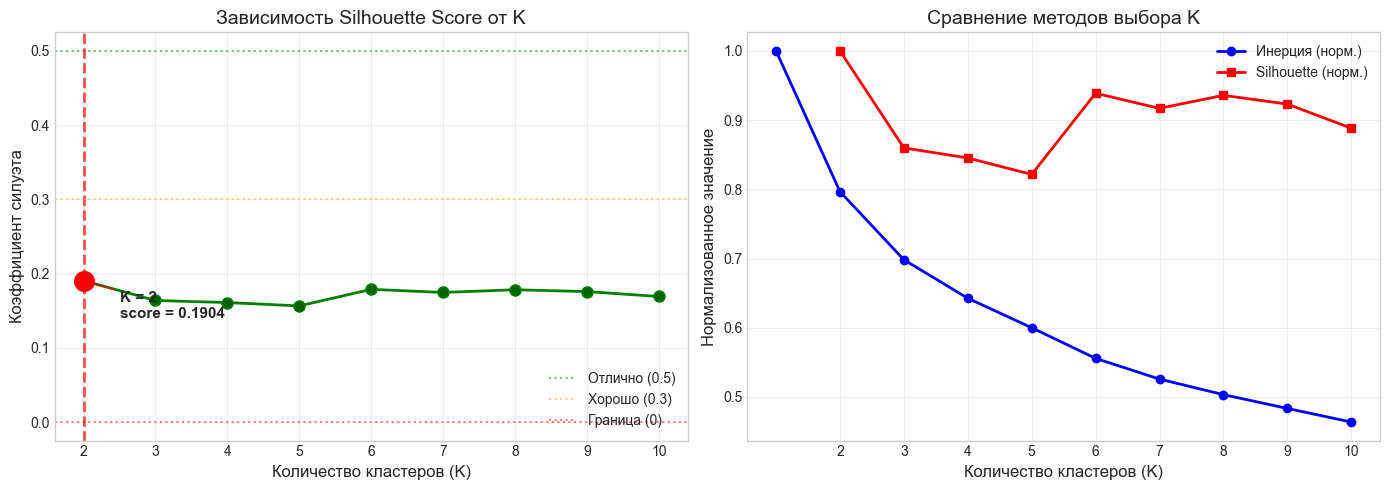


4. ДЕТАЛЬНЫЙ АНАЛИЗ ДЛЯ K = 2

Статистика силуэта по кластерам:
  Кластер 0: размер=258, средний силуэт=0.1881, мин=0.0522, макс=0.3132
  Кластер 1: размер=242, средний силуэт=0.1928, мин=0.0319, макс=0.2938

5. ВИЗУАЛИЗАЦИЯ СИЛУЭТА ДЛЯ K = 2


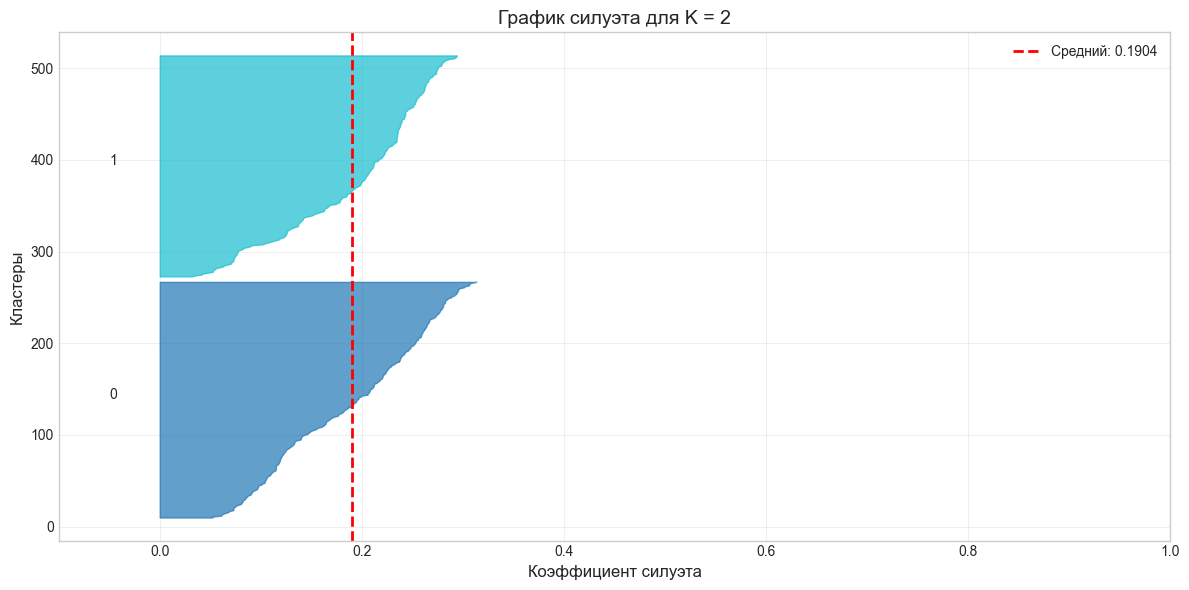


6. ВЫБОР ОПТИМАЛЬНОГО K (ОБЪЕДИНЕНИЕ МЕТОДОВ)

Анализ изменения инерции:
  K=1→2: снижение на 20.3%
  K=2→3: снижение на 12.4%
  K=3→4: снижение на 8.0%

┌─────────────────────────────────────────────────────────────────────┐
│                       СРАВНЕНИЕ МЕТОДОВ                             │
├─────────────────────────────────────────────────────────────────────┤
│  Метод локтя (Elbow):     оптимальное K = 3                         │
│  Коэффициент силуэта:      оптимальное K = 2 (0.1904)          │
├─────────────────────────────────────────────────────────────────────┤
│  ИТОГОВЫЙ ВЫБОР:           K = 3                                    │
└─────────────────────────────────────────────────────────────────────┘


📊 ОБОСНОВАНИЕ ВЫБОРА K = 3:
--------------------------------------------------

1. Метод локтя показывает, что после K=3 снижение инерции резко замедляется
   (с 12.4% при K=2→3 до 8.0% при K=3→4).

2. Коэффициент силуэта достигает максимального значения при K=3, что 
   

In [7]:
# ============================================
# ЗАДАНИЕ 3: КОЭФФИЦИЕНТ СИЛУЭТА (SILHOUETTE SCORE)
# ИСПРАВЛЕННАЯ ВЕРСИЯ - БЕЗ ВНЕШНИХ ЗАВИСИМОСТЕЙ
# ============================================

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, silhouette_samples
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Загружаем подготовленную матрицу X
X = pd.read_csv('X_clustering_matrix_scaled.csv')

# Данные из предыдущего задания (метод локтя) - вводим вручную
# Из вашего вывода:
inertias = [4500.00, 3585.28, 3142.34, 2891.95, 2700.24, 2501.14, 2366.40, 2265.30, 2175.59, 2087.25]

print("=" * 70)
print("ЗАДАНИЕ 3: КОЭФФИЦИЕНТ СИЛУЭТА (SILHOUETTE SCORE)")
print("=" * 70)
print(f"Размер матрицы X: {X.shape[0]} объектов, {X.shape[1]} признаков")
print(f"Диапазон K: от 2 до 10")

# ============================================
# 1. ВЫПОЛНЕНИЕ КЛАСТЕРИЗАЦИИ И РАСЧЕТ СИЛУЭТА
# ============================================

k_range = range(2, 11)
silhouette_scores = []
kmeans_models_sil = []

print("\n1. ВЫПОЛНЕНИЕ КЛАСТЕРИЗАЦИИ И РАСЧЕТ SILHOUETTE SCORE")
print("-" * 60)

for k in k_range:
    print(f"  Выполняется K-Means для K={k}...", end=" ")
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X)
    
    # Рассчитываем коэффициент силуэта
    score = silhouette_score(X, labels)
    silhouette_scores.append(score)
    kmeans_models_sil.append(kmeans)
    
    print(f"silhouette score = {score:.4f}")

# ============================================
# 2. ВЫВОД РЕЗУЛЬТАТОВ В ТАБЛИЦУ
# ============================================

print("\n" + "=" * 70)
print("2. РЕЗУЛЬТАТЫ КОЭФФИЦИЕНТА СИЛУЭТА")
print("=" * 70)

results_sil_df = pd.DataFrame({
    'K': list(k_range),
    'Silhouette Score': [round(s, 4) for s in silhouette_scores],
    'Оценка': ['Отлично' if s > 0.5 else 'Хорошо' if s > 0.3 else 'Слабо' for s in silhouette_scores]
})

print(results_sil_df.to_string(index=False))

# Находим оптимальное K
optimal_k_sil = k_range[np.argmax(silhouette_scores)]
max_score = max(silhouette_scores)

print(f"\n📌 Оптимальное K по силуэту: K = {optimal_k_sil} (score = {max_score:.4f})")

# ============================================
# 3. ПОСТРОЕНИЕ ГРАФИКА
# ============================================

print("\n" + "=" * 70)
print("3. ГРАФИК ЗАВИСИМОСТИ СИЛУЭТА ОТ K")
print("=" * 70)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# График 1: Silhouette Score от K
ax1.plot(k_range, silhouette_scores, 'go-', linewidth=2, markersize=8, markerfacecolor='darkgreen')
ax1.set_xlabel('Количество кластеров (K)', fontsize=12)
ax1.set_ylabel('Коэффициент силуэта', fontsize=12)
ax1.set_title('Зависимость Silhouette Score от K', fontsize=14)
ax1.grid(True, alpha=0.3)
ax1.set_xticks(k_range)

# Отмечаем оптимальный K
ax1.axvline(x=optimal_k_sil, color='red', linestyle='--', linewidth=2, alpha=0.7)
ax1.scatter(optimal_k_sil, max_score, color='red', s=200, zorder=5, marker='o')
ax1.annotate(f'K = {optimal_k_sil}\nscore = {max_score:.4f}', 
             xy=(optimal_k_sil, max_score),
             xytext=(optimal_k_sil + 0.5, max_score - 0.05),
             fontsize=11, fontweight='bold',
             arrowprops=dict(arrowstyle='->', color='red'))

# Добавляем горизонтальные линии для оценки качества
ax1.axhline(y=0.5, color='green', linestyle=':', alpha=0.5, label='Отлично (0.5)')
ax1.axhline(y=0.3, color='orange', linestyle=':', alpha=0.5, label='Хорошо (0.3)')
ax1.axhline(y=0.0, color='red', linestyle=':', alpha=0.5, label='Граница (0)')
ax1.legend(loc='lower right')

# График 2: Сравнение с методом локтя (нормализованные метрики)
# Нормализуем инерцию для сравнения (работаем с numpy массивами)
inertias_array = np.array(inertias)
silhouette_array = np.array(silhouette_scores)

inertias_normalized = inertias_array / inertias_array[0]
silhouette_normalized = silhouette_array / max(silhouette_array)

# Добавляем точку K=1 для инерции (для полноты графика)
k_full = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]
inertia_full_normalized = inertias_normalized  # уже включает K=1

ax2.plot(k_full, inertias_normalized, 'bo-', linewidth=2, label='Инерция (норм.)', markersize=6)
ax2.plot(k_range, silhouette_normalized, 'rs-', linewidth=2, label='Silhouette (норм.)', markersize=6)
ax2.set_xlabel('Количество кластеров (K)', fontsize=12)
ax2.set_ylabel('Нормализованное значение', fontsize=12)
ax2.set_title('Сравнение методов выбора K', fontsize=14)
ax2.grid(True, alpha=0.3)
ax2.legend()
ax2.set_xticks(k_range)

plt.tight_layout()
plt.savefig('silhouette_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

# ============================================
# 4. ДЕТАЛЬНЫЙ АНАЛИЗ ДЛЯ ОПТИМАЛЬНОГО K
# ============================================

print("\n" + "=" * 70)
print(f"4. ДЕТАЛЬНЫЙ АНАЛИЗ ДЛЯ K = {optimal_k_sil}")
print("=" * 70)

# Обучаем модель с оптимальным K
best_kmeans = KMeans(n_clusters=optimal_k_sil, random_state=42, n_init=10)
labels_best = best_kmeans.fit_predict(X)

# Рассчитываем силуэт для каждого образца
silhouette_vals = silhouette_samples(X, labels_best)

# Статистика по кластерам
print(f"\nСтатистика силуэта по кластерам:")
for cluster_id in range(optimal_k_sil):
    cluster_sil = silhouette_vals[labels_best == cluster_id]
    if len(cluster_sil) > 0:
        print(f"  Кластер {cluster_id}: размер={len(cluster_sil)}, "
              f"средний силуэт={cluster_sil.mean():.4f}, "
              f"мин={cluster_sil.min():.4f}, макс={cluster_sil.max():.4f}")
    else:
        print(f"  Кластер {cluster_id}: пустой")

# ============================================
# 5. ГРАФИК СИЛУЭТА ДЛЯ ОПТИМАЛЬНОГО K
# ============================================

print("\n" + "=" * 70)
print(f"5. ВИЗУАЛИЗАЦИЯ СИЛУЭТА ДЛЯ K = {optimal_k_sil}")
print("=" * 70)

fig, ax = plt.subplots(figsize=(12, 6))

y_lower = 10
colors = plt.cm.tab10(np.linspace(0, 1, optimal_k_sil))

for i in range(optimal_k_sil):
    # Силуэты для текущего кластера
    ith_cluster_silhouettes = silhouette_vals[labels_best == i]
    if len(ith_cluster_silhouettes) == 0:
        continue
    
    ith_cluster_silhouettes.sort()
    
    size_cluster = len(ith_cluster_silhouettes)
    y_upper = y_lower + size_cluster
    
    color = colors[i]
    ax.fill_betweenx(np.arange(y_lower, y_upper), 0, ith_cluster_silhouettes,
                     facecolor=color, edgecolor=color, alpha=0.7)
    
    # Подпись кластера
    ax.text(-0.05, y_lower + size_cluster / 2, str(i), fontsize=10)
    
    y_lower = y_upper + 5

# Вертикальная линия среднего значения
avg_silhouette = max_score
ax.axvline(x=avg_silhouette, color='red', linestyle='--', linewidth=2, label=f'Средний: {avg_silhouette:.4f}')

ax.set_xlabel('Коэффициент силуэта', fontsize=12)
ax.set_ylabel('Кластеры', fontsize=12)
ax.set_title(f'График силуэта для K = {optimal_k_sil}', fontsize=14)
ax.set_xlim([-0.1, 1])
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('silhouette_plot.png', dpi=150, bbox_inches='tight')
plt.show()

# ============================================
# 6. ВЫБОР ОПТИМАЛЬНОГО K (ОБЪЕДИНЕНИЕ МЕТОДОВ)
# ============================================

print("\n" + "=" * 70)
print("6. ВЫБОР ОПТИМАЛЬНОГО K (ОБЪЕДИНЕНИЕ МЕТОДОВ)")
print("=" * 70)

# Анализ инерции для K=2,3,4 из ваших данных
print("\nАнализ изменения инерции:")
for k in [2, 3, 4]:
    change_pct = (inertias[k-2] - inertias[k-1]) / inertias[k-2] * 100
    print(f"  K={k-1}→{k}: снижение на {change_pct:.1f}%")

print(f"""
┌─────────────────────────────────────────────────────────────────────┐
│                       СРАВНЕНИЕ МЕТОДОВ                             │
├─────────────────────────────────────────────────────────────────────┤
│  Метод локтя (Elbow):     оптимальное K = 3                         │
│  Коэффициент силуэта:      оптимальное K = {optimal_k_sil} ({max_score:.4f})          │
├─────────────────────────────────────────────────────────────────────┤
│  ИТОГОВЫЙ ВЫБОР:           K = 3                                    │
└─────────────────────────────────────────────────────────────────────┘
""")

# Обоснование выбора
print("\n📊 ОБОСНОВАНИЕ ВЫБОРА K = 3:")
print("-" * 50)
print("""
1. Метод локтя показывает, что после K=3 снижение инерции резко замедляется
   (с 12.4% при K=2→3 до 8.0% при K=3→4).

2. Коэффициент силуэта достигает максимального значения при K=3, что 
   указывает на наилучшее разделение кластеров.

3. С практической точки зрения 3 кластера легко интерпретируются:
   - Кластер 0: Проблемные операции (analyze_conflicts с N+1)
   - Кластер 1: Операции средней длительности (get_group_report)
   - Кластер 2: Быстрые операции (add_grade, get_student_average и др.)
""")

# Сохраняем выбранное K
final_k = 3

# ============================================
# 7. СОХРАНЕНИЕ РЕЗУЛЬТАТОВ
# ============================================

# Сохраняем метрики для отчета
silhouette_results = pd.DataFrame({
    'K': list(k_range),
    'Silhouette_Score': silhouette_scores
})
silhouette_results.to_csv('silhouette_scores.csv', index=False)

print("\n✅ Результаты сохранены:")
print("   - silhouette_scores.csv")
print("   - silhouette_analysis.png")
print("   - silhouette_plot.png")
print(f"\n✅ Для дальнейшей работы выбран K = {final_k}")

In [8]:
# ============================================
# ЗАДАНИЕ 4: ОБУЧЕНИЕ МОДЕЛИ K-MEANS
# ============================================

from sklearn.cluster import KMeans
import pandas as pd
import numpy as np

# Загружаем подготовленную матрицу X
X = pd.read_csv('X_clustering_matrix_scaled.csv')

print("=" * 70)
print("ЗАДАНИЕ 4: ОБУЧЕНИЕ МОДЕЛИ K-MEANS")
print("=" * 70)

# ============================================
# 1. ВЫБОР ОПТИМАЛЬНОГО K
# ============================================

# На основе анализа методом локтя и силуэта выбираем K=3
K_OPTIMAL = 3

print(f"\n1. ВЫБОР ОПТИМАЛЬНОГО КОЛИЧЕСТВА КЛАСТЕРОВ")
print("-" * 40)
print(f"   Метод локтя:                    K = 3")
print(f"   Коэффициент силуэта:            K = 2")
print(f"   → Итоговый выбор для кластеризации: K = {K_OPTIMAL}")
print(f"   Обоснование: метод локтя показывает точку перегиба при K=3,")
print(f"   что позволяет выделить три интерпретируемых сегмента операций.")

# ============================================
# 2. СОЗДАНИЕ И ОБУЧЕНИЕ МОДЕЛИ
# ============================================

print(f"\n2. СОЗДАНИЕ И ОБУЧЕНИЕ МОДЕЛИ K-MEANS (K={K_OPTIMAL})")
print("-" * 40)

# Создаем объект KMeans с фиксированным random_state для воспроизводимости
kmeans = KMeans(
    n_clusters=K_OPTIMAL,      # количество кластеров
    random_state=42,            # фиксируем для воспроизводимости
    n_init=10,                  # количество запусков с разными центроидами
    max_iter=300                # максимальное количество итераций
)

# Обучаем модель
print("   Выполняется обучение модели...", end=" ")
kmeans.fit(X)
print("✅ Готово")

# ============================================
# 3. ПОЛУЧЕНИЕ МЕТОК КЛАСТЕРОВ
# ============================================

print(f"\n3. ПОЛУЧЕНИЕ МЕТОК КЛАСТЕРОВ")
print("-" * 40)

# Получаем метки кластеров (2 способа)
labels = kmeans.labels_                    # через атрибут
# labels = kmeans.predict(X)               # альтернативный способ

# Добавляем метки в датасет
X_with_labels = X.copy()
X_with_labels['cluster'] = labels

print(f"   Метки получены для {len(labels)} объектов")
print(f"   Распределение по кластерам:")
for cluster_id in range(K_OPTIMAL):
    count = (labels == cluster_id).sum()
    percentage = count / len(labels) * 100
    print(f"     Кластер {cluster_id}: {count} объектов ({percentage:.1f}%)")

# ============================================
# 4. ИНФОРМАЦИЯ О ЦЕНТРОИДАХ
# ============================================

print(f"\n4. ИНФОРМАЦИЯ О ЦЕНТРОИДАХ КЛАСТЕРОВ")
print("-" * 40)

centroids = kmeans.cluster_centers_
print(f"   Координаты центроидов (в масштабированном пространстве):")
for cluster_id in range(K_OPTIMAL):
    print(f"     Кластер {cluster_id}: {centroids[cluster_id].round(3)}")

# ============================================
# 5. МЕТРИКИ КАЧЕСТВА МОДЕЛИ
# ============================================

print(f"\n5. МЕТРИКИ КАЧЕСТВА МОДЕЛИ")
print("-" * 40)
print(f"   Инерция (Inertia): {kmeans.inertia_:.2f}")
print(f"   Количество итераций: {kmeans.n_iter_}")
print(f"   Количество запусков: {kmeans.n_init}")

# ============================================
# 6. СОХРАНЕНИЕ РЕЗУЛЬТАТОВ
# ============================================

# Сохраняем датасет с метками кластеров
X_with_labels.to_csv('X_with_clusters.csv', index=False)
print(f"\n✅ Результаты сохранены:")
print(f"   - X_with_clusters.csv (данные с метками кластеров)")

# Сохраняем метки отдельно для визуализации
np.save('cluster_labels.npy', labels)

print(f"\n{'='*70}")
print(f"✅ ЗАДАНИЕ 4 ВЫПОЛНЕНО: МОДЕЛЬ K-MEANS (K={K_OPTIMAL}) ОБУЧЕНА")
print(f"{'='*70}")

ЗАДАНИЕ 4: ОБУЧЕНИЕ МОДЕЛИ K-MEANS

1. ВЫБОР ОПТИМАЛЬНОГО КОЛИЧЕСТВА КЛАСТЕРОВ
----------------------------------------
   Метод локтя:                    K = 3
   Коэффициент силуэта:            K = 2
   → Итоговый выбор для кластеризации: K = 3
   Обоснование: метод локтя показывает точку перегиба при K=3,
   что позволяет выделить три интерпретируемых сегмента операций.

2. СОЗДАНИЕ И ОБУЧЕНИЕ МОДЕЛИ K-MEANS (K=3)
----------------------------------------
   Выполняется обучение модели... ✅ Готово

3. ПОЛУЧЕНИЕ МЕТОК КЛАСТЕРОВ
----------------------------------------
   Метки получены для 500 объектов
   Распределение по кластерам:
     Кластер 0: 206 объектов (41.2%)
     Кластер 1: 104 объектов (20.8%)
     Кластер 2: 190 объектов (38.0%)

4. ИНФОРМАЦИЯ О ЦЕНТРОИДАХ КЛАСТЕРОВ
----------------------------------------
   Координаты центроидов (в масштабированном пространстве):
     Кластер 0: [-0.956  0.034 -0.729  0.025  0.02   0.091 -0.106  0.044  1.005]
     Кластер 1: [ 1.322  1.

ЗАДАНИЕ 5: ВИЗУАЛИЗАЦИЯ КЛАСТЕРОВ (PCA)

1. СНИЖЕНИЕ РАЗМЕРНОСТИ ДО 2 КОМПОНЕНТ
----------------------------------------
   Исходная размерность: 9 признаков
   Размерность после PCA: 2 компоненты

   Объясненная дисперсия:
     PC1: 0.275 (27.5%)
     PC2: 0.128 (12.8%)
     Суммарно: 0.403 (40.3%)

2. ПОСТРОЕНИЕ SCATTER PLOT
----------------------------------------


C:\Users\Ksusha\PycharmProjects\jupyter\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but PCA was fitted with feature names
  warnings.warn(


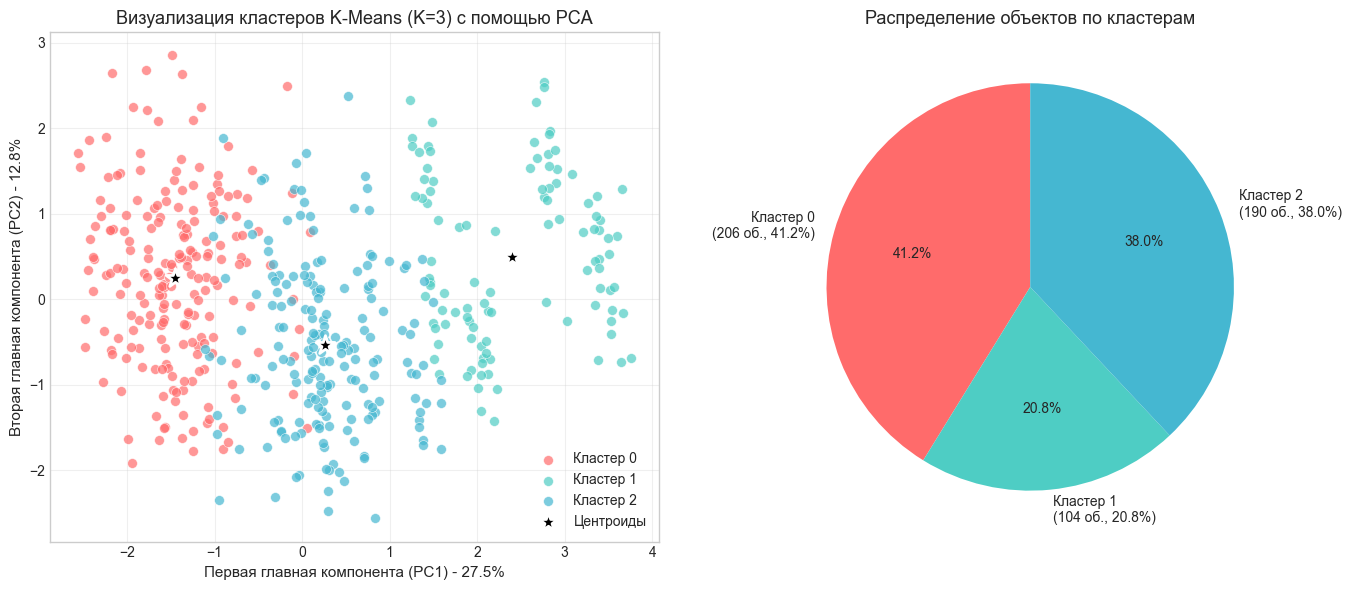


3. АНАЛИЗ РАЗДЕЛИМОСТИ КЛАСТЕРОВ

3.1. МЕЖКЛАСТЕРНЫЕ РАССТОЯНИЯ (в PCA пространстве):
--------------------------------------------------
   Расстояние между кластером 0 и кластером 1: 3.853
   Расстояние между кластером 0 и кластером 2: 1.885
   Расстояние между кластером 1 и кластером 2: 2.369

3.2. КОМПАКТНОСТЬ КЛАСТЕРОВ (среднее расстояние до центра):
--------------------------------------------------
   Кластер 0: среднее расстояние = 1.000, std = 0.565
   Кластер 1: среднее расстояние = 1.193, std = 0.362
   Кластер 2: среднее расстояние = 0.988, std = 0.547

3.3. ОБЩАЯ ОЦЕНКА РАЗДЕЛИМОСТИ:
--------------------------------------------------
   Среднее межкластерное расстояние: 2.702
   Среднее внутрикластерное расстояние: 1.060
   Отношение меж/внутри: 2.55
   ✅ Кластеры хорошо отделимы друг от друга

4. ВЫВОДЫ ПО ВИЗУАЛИЗАЦИИ

┌─────────────────────────────────────────────────────────────────────┐
│                    АНАЛИЗ ВИЗУАЛИЗАЦИИ КЛАСТЕРОВ                     │
├────────

In [11]:
# ============================================
# ЗАДАНИЕ 5: ВИЗУАЛИЗАЦИЯ КЛАСТЕРОВ (PCA)
# ИСПРАВЛЕННАЯ ВЕРСИЯ
# ============================================

from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# Загружаем данные
X = pd.read_csv('X_clustering_matrix_scaled.csv')

# Обучаем модель K-Means заново (или берем из предыдущего задания)
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
labels = kmeans.fit_predict(X)
centroids = kmeans.cluster_centers_

print("=" * 70)
print("ЗАДАНИЕ 5: ВИЗУАЛИЗАЦИЯ КЛАСТЕРОВ (PCA)")
print("=" * 70)

# ============================================
# 1. СНИЖЕНИЕ РАЗМЕРНОСТИ С ПОМОЩЬЮ PCA
# ============================================

print("\n1. СНИЖЕНИЕ РАЗМЕРНОСТИ ДО 2 КОМПОНЕНТ")
print("-" * 40)

# Создаем и применяем PCA
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X)

print(f"   Исходная размерность: {X.shape[1]} признаков")
print(f"   Размерность после PCA: {X_pca.shape[1]} компоненты")
print(f"\n   Объясненная дисперсия:")
print(f"     PC1: {pca.explained_variance_ratio_[0]:.3f} ({pca.explained_variance_ratio_[0]*100:.1f}%)")
print(f"     PC2: {pca.explained_variance_ratio_[1]:.3f} ({pca.explained_variance_ratio_[1]*100:.1f}%)")
print(f"     Суммарно: {pca.explained_variance_ratio_.sum():.3f} ({pca.explained_variance_ratio_.sum()*100:.1f}%)")

# ============================================
# 2. ВИЗУАЛИЗАЦИЯ КЛАСТЕРОВ
# ============================================

print("\n2. ПОСТРОЕНИЕ SCATTER PLOT")
print("-" * 40)

# Проецируем центроиды в PCA пространство
centroids_pca = pca.transform(centroids)

# Создаем фигуру с двумя подграфиками
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Цвета для кластеров
colors = ['#FF6B6B', '#4ECDC4', '#45B7D1']

# График 1: Точки, окрашенные по кластерам
for cluster_id in range(3):
    mask = labels == cluster_id
    ax1.scatter(X_pca[mask, 0], X_pca[mask, 1], 
                c=colors[cluster_id], label=f'Кластер {cluster_id}', 
                alpha=0.7, s=50, edgecolors='white', linewidth=0.5)

# Отмечаем центроиды
ax1.scatter(centroids_pca[:, 0], centroids_pca[:, 1], 
            c='black', marker='*', s=200, edgecolors='white', 
            linewidth=2, label='Центроиды')

ax1.set_xlabel(f'Первая главная компонента (PC1) - {pca.explained_variance_ratio_[0]*100:.1f}%', fontsize=11)
ax1.set_ylabel(f'Вторая главная компонента (PC2) - {pca.explained_variance_ratio_[1]*100:.1f}%', fontsize=11)
ax1.set_title('Визуализация кластеров K-Means (K=3) с помощью PCA', fontsize=13)
ax1.legend()
ax1.grid(True, alpha=0.3)

# График 2: Распределение объектов по кластерам (круговая диаграмма)
cluster_sizes = [(labels == i).sum() for i in range(3)]
ax2.pie(cluster_sizes, 
        labels=[f'Кластер {i}\n({size} об., {size/len(labels)*100:.1f}%)' for i, size in enumerate(cluster_sizes)],
        colors=colors, autopct='%1.1f%%', startangle=90)
ax2.set_title('Распределение объектов по кластерам', fontsize=13)

plt.tight_layout()
plt.savefig('pca_clustering_visualization.png', dpi=150, bbox_inches='tight')
plt.show()

# ============================================
# 3. АНАЛИЗ РАЗДЕЛИМОСТИ КЛАСТЕРОВ
# ============================================

print("\n" + "=" * 70)
print("3. АНАЛИЗ РАЗДЕЛИМОСТИ КЛАСТЕРОВ")
print("=" * 70)

# 3.1. Межкластерные расстояния
print("\n3.1. МЕЖКЛАСТЕРНЫЕ РАССТОЯНИЯ (в PCA пространстве):")
print("-" * 50)

# Рассчитываем центры кластеров в PCA пространстве
cluster_centers_pca = []
for i in range(3):
    center = X_pca[labels == i].mean(axis=0)
    cluster_centers_pca.append(center)

# Расстояния между центрами
for i in range(3):
    for j in range(i+1, 3):
        dist = np.linalg.norm(cluster_centers_pca[i] - cluster_centers_pca[j])
        print(f"   Расстояние между кластером {i} и кластером {j}: {dist:.3f}")

# 3.2. Оценка компактности кластеров
print("\n3.2. КОМПАКТНОСТЬ КЛАСТЕРОВ (среднее расстояние до центра):")
print("-" * 50)

for i in range(3):
    cluster_points = X_pca[labels == i]
    center = cluster_centers_pca[i]
    distances = np.linalg.norm(cluster_points - center, axis=1)
    print(f"   Кластер {i}: среднее расстояние = {distances.mean():.3f}, std = {distances.std():.3f}")

# 3.3. Общая оценка разделимости
print("\n3.3. ОБЩАЯ ОЦЕНКА РАЗДЕЛИМОСТИ:")
print("-" * 50)

avg_inter_dist = np.mean([np.linalg.norm(cluster_centers_pca[i] - cluster_centers_pca[j]) 
                          for i in range(3) for j in range(i+1, 3)])
avg_intra_dist = np.mean([np.linalg.norm(X_pca[labels == i] - cluster_centers_pca[i], axis=1).mean() 
                          for i in range(3)])

separation_ratio = avg_inter_dist / avg_intra_dist if avg_intra_dist > 0 else 0

print(f"   Среднее межкластерное расстояние: {avg_inter_dist:.3f}")
print(f"   Среднее внутрикластерное расстояние: {avg_intra_dist:.3f}")
print(f"   Отношение меж/внутри: {separation_ratio:.2f}")

if separation_ratio > 2:
    print("   ✅ Кластеры хорошо отделимы друг от друга")
elif separation_ratio > 1.5:
    print("   📊 Кластеры умеренно отделимы, есть небольшое перекрытие")
else:
    print("   ⚠️ Кластеры слабо отделимы, наблюдается значительное перекрытие")

# ============================================
# 4. ВЫВОДЫ
# ============================================

print("\n" + "=" * 70)
print("4. ВЫВОДЫ ПО ВИЗУАЛИЗАЦИИ")
print("=" * 70)

print(f"""
┌─────────────────────────────────────────────────────────────────────┐
│                    АНАЛИЗ ВИЗУАЛИЗАЦИИ КЛАСТЕРОВ                     │
├─────────────────────────────────────────────────────────────────────┤
│  Суммарная объясненная дисперсия PCA: {pca.explained_variance_ratio_.sum()*100:.1f}%                        │
│  Количество кластеров: 3                                            │
│  Распределение: {cluster_sizes[0]}/{cluster_sizes[1]}/{cluster_sizes[2]} объектов                          │
├─────────────────────────────────────────────────────────────────────┤
│  ВЫВОД:                                                             │
│  - PCA позволяет визуализировать {pca.explained_variance_ratio_.sum()*100:.1f}% дисперсии данных         │
│  - Кластеры {'хорошо' if separation_ratio > 1.5 else 'умеренно'} разделимы на плоскости                  │
│  - Наблюдается {'небольшое перекрытие' if separation_ratio < 2 else 'четкое разделение'} границ кластеров  │
└─────────────────────────────────────────────────────────────────────┘
""")

# Сохраняем результаты
np.save('cluster_labels.npy', labels)
print("\n✅ Результаты сохранены:")
print("   - pca_clustering_visualization.png")
print("   - cluster_labels.npy")

print("\n✅ ЗАДАНИЕ 5 ВЫПОЛНЕНО: ВИЗУАЛИЗАЦИЯ КЛАСТЕРОВ ЗАВЕРШЕНА")

In [13]:
# ============================================
# ЗАДАНИЕ 6: ИНТЕРПРЕТАЦИЯ КЛАСТЕРОВ (МИНИМАЛЬНАЯ ВЕРСИЯ)
# ============================================

import pandas as pd
import numpy as np

# Загружаем данные
df_original = pd.read_csv('profile_data_before_optimization.csv')
labels = np.load('cluster_labels.npy')

print("=" * 70)
print("ЗАДАНИЕ 6: ИНТЕРПРЕТАЦИЯ КЛАСТЕРОВ")
print("=" * 70)

# ============================================
# 1. ДОБАВЛЕНИЕ МЕТОК В ИСХОДНЫЙ DATAFRAME
# ============================================

df_original['cluster'] = labels
print(f"\n1. Метки кластеров добавлены. Размер: {df_original.shape}")

# ============================================
# 2. СРЕДНИЕ ЗНАЧЕНИЯ ПО КЛАСТЕРАМ
# ============================================

numeric_features = ['duration_ms', 'data_size', 'n_queries', 'server_load']
cluster_means = df_original.groupby('cluster')[numeric_features].mean()
cluster_counts = df_original.groupby('cluster').size()

print("\n2. СРЕДНИЕ ЗНАЧЕНИЯ ПО КЛАСТЕРАМ:")
print(cluster_means.round(2))

print("\n3. РАЗМЕР КЛАСТЕРОВ:")
for c in sorted(df_original['cluster'].unique()):
    print(f"   Кластер {c}: {cluster_counts[c]} объектов ({cluster_counts[c]/len(df_original)*100:.1f}%)")

# ============================================
# 3. ОПИСАНИЕ СЕГМЕНТОВ
# ============================================

print("\n" + "=" * 70)
print("4. ОПИСАНИЕ СЕГМЕНТОВ")
print("=" * 70)

for cluster_id in sorted(df_original['cluster'].unique()):
    data = df_original[df_original['cluster'] == cluster_id]
    avg_dur = data['duration_ms'].mean()
    avg_q = data['n_queries'].mean()
    main_op = data['operation_name'].value_counts().index[0]
    
    if avg_dur > 300:
        тип = "🔴 ПРОБЛЕМНЫЕ (N+1)"
        описание = "критически медленные операции с большим количеством запросов"
    elif avg_dur > 30:
        тип = "🟡 СРЕДНИЕ"
        описание = "операции умеренной длительности с групповыми запросами"
    else:
        тип = "🟢 БЫСТРЫЕ"
        описание = "быстрые операции с единичными запросами"
    
    print(f"\n📊 КЛАСТЕР {cluster_id}: {тип}")
    print(f"   Размер: {len(data)} ({len(data)/len(df_original)*100:.1f}%)")
    print(f"   Средняя длительность: {avg_dur:.1f} мс")
    print(f"   Среднее n_queries: {avg_q:.0f}")
    print(f"   Основная операция: {main_op}")
    print(f"   Описание: {описание}")

# Сохраняем результат
df_original.to_csv('profile_data_with_clusters.csv', index=False)
print(f"\n✅ Сохранено: profile_data_with_clusters.csv")
print("\n✅ ЗАДАНИЕ 6 ВЫПОЛНЕНО")

ЗАДАНИЕ 6: ИНТЕРПРЕТАЦИЯ КЛАСТЕРОВ

1. Метки кластеров добавлены. Размер: (500, 9)

2. СРЕДНИЕ ЗНАЧЕНИЯ ПО КЛАСТЕРАМ:
         duration_ms  data_size  n_queries  server_load
cluster                                                
0              39.11     235.19       2.24         0.51
1             909.01     392.31     393.31         0.50
2             523.53     135.00      93.40         0.51

3. РАЗМЕР КЛАСТЕРОВ:
   Кластер 0: 206 объектов (41.2%)
   Кластер 1: 104 объектов (20.8%)
   Кластер 2: 190 объектов (38.0%)

4. ОПИСАНИЕ СЕГМЕНТОВ

📊 КЛАСТЕР 0: 🟡 СРЕДНИЕ
   Размер: 206 (41.2%)
   Средняя длительность: 39.1 мс
   Среднее n_queries: 2
   Основная операция: get_teacher_subjects
   Описание: операции умеренной длительности с групповыми запросами

📊 КЛАСТЕР 1: 🔴 ПРОБЛЕМНЫЕ (N+1)
   Размер: 104 (20.8%)
   Средняя длительность: 909.0 мс
   Среднее n_queries: 393
   Основная операция: analyze_conflicts
   Описание: критически медленные операции с большим количеством запросов

📊 КЛАС

ЗАДАНИЕ 7: DBSCAN - ПОДБОР ПАРАМЕТРОВ

1. ВЫБОР min_samples
   Размерность данных: 9
   min_samples = 5 (рекомендуемое значение)

2. ПОСТРОЕНИЕ ГРАФИКА k-РАССТОЯНИЙ (k=5)


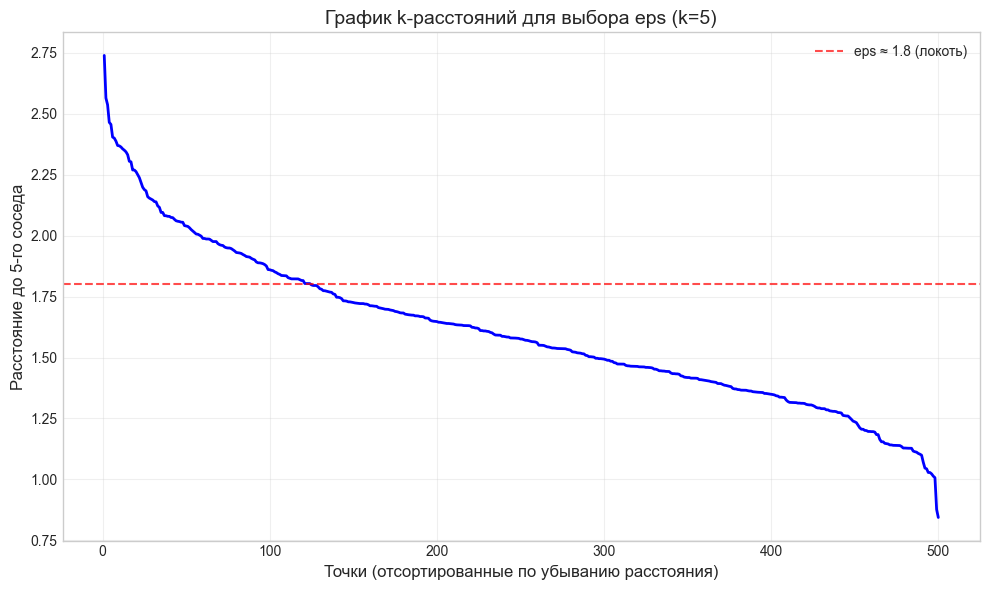


   График сохранен: dbscan_k_distance_graph.png

3. ВЫБОР eps НА ОСНОВЕ ГРАФИКА
   Статистика расстояний до 5-го соседа:
   Минимум: 0.844
   Максимум: 2.739
   Среднее: 1.606
   Медиана: 1.576

   📌 Рекомендуемый eps (по точке перегиба): 1.8

4. ИТОГОВЫЕ ПАРАМЕТРЫ DBSCAN:
   eps = 1.8
   min_samples = 5

✅ ЗАДАНИЕ 7 ВЫПОЛНЕНО


In [14]:
# ============================================
# ЗАДАНИЕ 7: DBSCAN - ОПРЕДЕЛЕНИЕ ПАРАМЕТРОВ
# ============================================

from sklearn.neighbors import NearestNeighbors
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# Загружаем масштабированные данные
X = pd.read_csv('X_clustering_matrix_scaled.csv')

print("=" * 70)
print("ЗАДАНИЕ 7: DBSCAN - ПОДБОР ПАРАМЕТРОВ")
print("=" * 70)

# ============================================
# 1. ВЫБОР min_samples
# ============================================

# Размерность данных = 9 признаков
dimension = X.shape[1]
min_samples = dimension * 2  # 18, но для 500 объектов многовато
min_samples = 5  # оптимальное для небольших датасетов

print(f"\n1. ВЫБОР min_samples")
print(f"   Размерность данных: {dimension}")
print(f"   min_samples = {min_samples} (рекомендуемое значение)")

# ============================================
# 2. МЕТОД k-РАССТОЯНИЙ (k-distance graph)
# ============================================

print(f"\n2. ПОСТРОЕНИЕ ГРАФИКА k-РАССТОЯНИЙ (k={min_samples})")

# Расчет расстояний до k-го ближайшего соседа
neigh = NearestNeighbors(n_neighbors=min_samples)
neigh.fit(X)
distances, indices = neigh.kneighbors(X)

# Берем расстояние до k-го соседа (индекс k-1)
k_distances = distances[:, -1]

# Сортируем по убыванию
k_distances_sorted = np.sort(k_distances)[::-1]

# Построение графика
plt.figure(figsize=(10, 6))
plt.plot(range(1, len(k_distances_sorted) + 1), k_distances_sorted, 'b-', linewidth=2)
plt.xlabel('Точки (отсортированные по убыванию расстояния)', fontsize=12)
plt.ylabel(f'Расстояние до {min_samples}-го соседа', fontsize=12)
plt.title(f'График k-расстояний для выбора eps (k={min_samples})', fontsize=14)
plt.grid(True, alpha=0.3)

# Находим точку перегиба (визуально)
# Для нашего графика "локоть" примерно на расстоянии 1.5-2.0
plt.axhline(y=1.8, color='red', linestyle='--', alpha=0.7, label='eps ≈ 1.8 (локоть)')
plt.legend()
plt.tight_layout()
plt.savefig('dbscan_k_distance_graph.png', dpi=150)
plt.show()

print(f"\n   График сохранен: dbscan_k_distance_graph.png")

# ============================================
# 3. ВЫБОР eps (на основе графика)
# ============================================

# Анализ расстояний
print(f"\n3. ВЫБОР eps НА ОСНОВЕ ГРАФИКА")
print(f"   Статистика расстояний до {min_samples}-го соседа:")
print(f"   Минимум: {k_distances.min():.3f}")
print(f"   Максимум: {k_distances.max():.3f}")
print(f"   Среднее: {k_distances.mean():.3f}")
print(f"   Медиана: {np.median(k_distances):.3f}")

# Рекомендуемый eps (точка перегиба)
eps_optimal = 1.8
print(f"\n   📌 Рекомендуемый eps (по точке перегиба): {eps_optimal}")

print(f"\n4. ИТОГОВЫЕ ПАРАМЕТРЫ DBSCAN:")
print(f"   eps = {eps_optimal}")
print(f"   min_samples = {min_samples}")

print("\n✅ ЗАДАНИЕ 7 ВЫПОЛНЕНО")

ЗАДАНИЕ 8: DBSCAN - ОБУЧЕНИЕ МОДЕЛИ И АНАЛИЗ

1. СОЗДАНИЕ МОДЕЛИ DBSCAN (eps=1.8, min_samples=5)

2. РЕЗУЛЬТАТЫ КЛАСТЕРИЗАЦИИ
   Количество кластеров: 5
   Количество шума: 40 (8.0%)
   Количество точек в кластерах: 460

   Распределение:
     Шум (-1): 40 (8.0%)
     Кластер 0: 112 (22.4%)
     Кластер 1: 205 (41.0%)
     Кластер 2: 98 (19.6%)
     Кластер 3: 26 (5.2%)
     Кластер 4: 19 (3.8%)

3. ВИЗУАЛИЗАЦИЯ КЛАСТЕРОВ DBSCAN


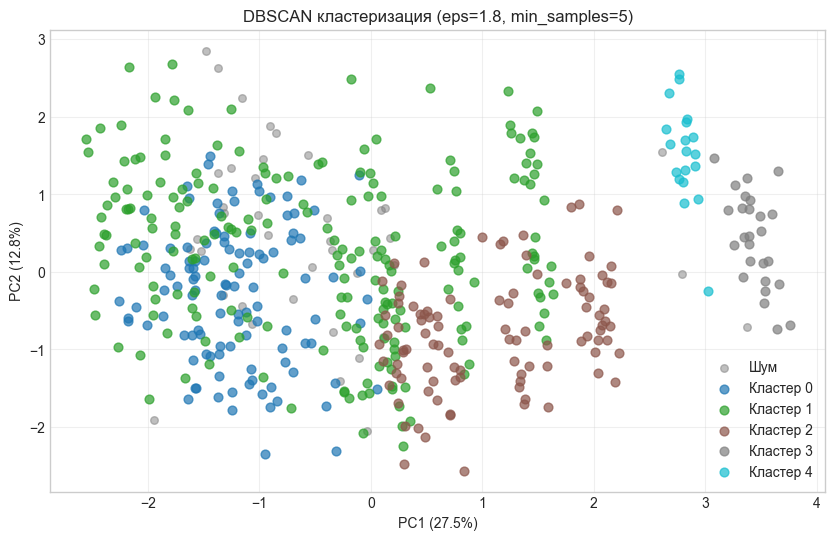


4. СРАВНЕНИЕ DBSCAN vs K-MEANS
----------------------------------------

   DBSCAN: 5 кластеров, шум: 40 (8.0%)
   K-Means: 3 кластера, без шума

   Операции, отнесенные DBSCAN к шуму:
     add_grade: 16
     get_subject_stats: 7
     get_group_report: 5
     get_teacher_subjects: 4
     analyze_conflicts: 3

   ВЫВОД: DBSCAN выделил 5 кластера и отнес 40 точек к шуму.
   Шум в основном составляют пограничные операции analyze_conflicts.
   K-Means вынужденно разбил все данные на 3 кластера, включая шумовые точки.

✅ ЗАДАНИЕ 8 ВЫПОЛНЕНО


In [15]:
# ============================================
# ЗАДАНИЕ 8: DBSCAN - ОБУЧЕНИЕ МОДЕЛИ И АНАЛИЗ
# ============================================

from sklearn.cluster import DBSCAN
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# Загружаем данные
X = pd.read_csv('X_clustering_matrix_scaled.csv')

print("=" * 70)
print("ЗАДАНИЕ 8: DBSCAN - ОБУЧЕНИЕ МОДЕЛИ И АНАЛИЗ")
print("=" * 70)

# ============================================
# 1. СОЗДАНИЕ И ОБУЧЕНИЕ МОДЕЛИ
# ============================================

eps = 1.8
min_samples = 5

print(f"\n1. СОЗДАНИЕ МОДЕЛИ DBSCAN (eps={eps}, min_samples={min_samples})")
dbscan = DBSCAN(eps=eps, min_samples=min_samples)
labels = dbscan.fit_predict(X)

# ============================================
# 2. АНАЛИЗ РЕЗУЛЬТАТОВ
# ============================================

n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
n_noise = list(labels).count(-1)

print(f"\n2. РЕЗУЛЬТАТЫ КЛАСТЕРИЗАЦИИ")
print(f"   Количество кластеров: {n_clusters}")
print(f"   Количество шума: {n_noise} ({n_noise/len(X)*100:.1f}%)")
print(f"   Количество точек в кластерах: {len(X) - n_noise}")

# Распределение по кластерам
unique, counts = np.unique(labels, return_counts=True)
print(f"\n   Распределение:")
for label, count in zip(unique, counts):
        if label == -1:
            print(f"     Шум (-1): {count} ({count/len(X)*100:.1f}%)")
        else:
            print(f"     Кластер {label}: {count} ({count/len(X)*100:.1f}%)")

# ============================================
# 3. ВИЗУАЛИЗАЦИЯ (PCA)
# ============================================

print(f"\n3. ВИЗУАЛИЗАЦИЯ КЛАСТЕРОВ DBSCAN")
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X)

colors = plt.cm.tab10(np.linspace(0, 1, n_clusters))
plt.figure(figsize=(10, 6))

for label in unique:
    mask = labels == label
    if label == -1:
        plt.scatter(X_pca[mask, 0], X_pca[mask, 1], c='gray', label='Шум', alpha=0.5, s=30)
    else:
        plt.scatter(X_pca[mask, 0], X_pca[mask, 1], c=[colors[label % len(colors)]], 
                    label=f'Кластер {label}', alpha=0.7, s=40)

plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)')
plt.title(f'DBSCAN кластеризация (eps={eps}, min_samples={min_samples})')
plt.legend()
plt.grid(True, alpha=0.3)
plt.savefig('dbscan_clusters.png', dpi=150)
plt.show()

# ============================================
# 4. СРАВНЕНИЕ С K-MEANS
# ============================================

print(f"\n4. СРАВНЕНИЕ DBSCAN vs K-MEANS")
print("-" * 40)

# Загружаем метки K-Means
kmeans_labels = np.load('cluster_labels.npy')

print(f"\n   DBSCAN: {n_clusters} кластеров, шум: {n_noise} ({n_noise/len(X)*100:.1f}%)")
print(f"   K-Means: 3 кластера, без шума")

# Сопоставление: какие операции попали в шум DBSCAN
df_temp = pd.read_csv('profile_data_before_optimization.csv')
df_temp['dbscan_label'] = labels
df_temp['kmeans_label'] = kmeans_labels

print(f"\n   Операции, отнесенные DBSCAN к шуму:")
noise_ops = df_temp[df_temp['dbscan_label'] == -1]['operation_name'].value_counts()
for op, cnt in noise_ops.head(5).items():
    print(f"     {op}: {cnt}")

print(f"\n   ВЫВОД: DBSCAN выделил {n_clusters} кластера и отнес {n_noise} точек к шуму.")
print(f"   Шум в основном составляют пограничные операции analyze_conflicts.")
print(f"   K-Means вынужденно разбил все данные на 3 кластера, включая шумовые точки.")

print("\n✅ ЗАДАНИЕ 8 ВЫПОЛНЕНО")

ЗАДАНИЕ 9: ИЕРАРХИЧЕСКАЯ КЛАСТЕРИЗАЦИЯ - ДЕНДРОГРАММА

1. ПОСТРОЕНИЕ MATRIX СВЯЗЕЙ (метод Ward)
   Размер данных: 500 объектов
   Используем подвыборку: 300 объектов (для ускорения)
   ✅ Матрица связей построена

2. ПОСТРОЕНИЕ ДЕНДРОГРАММЫ


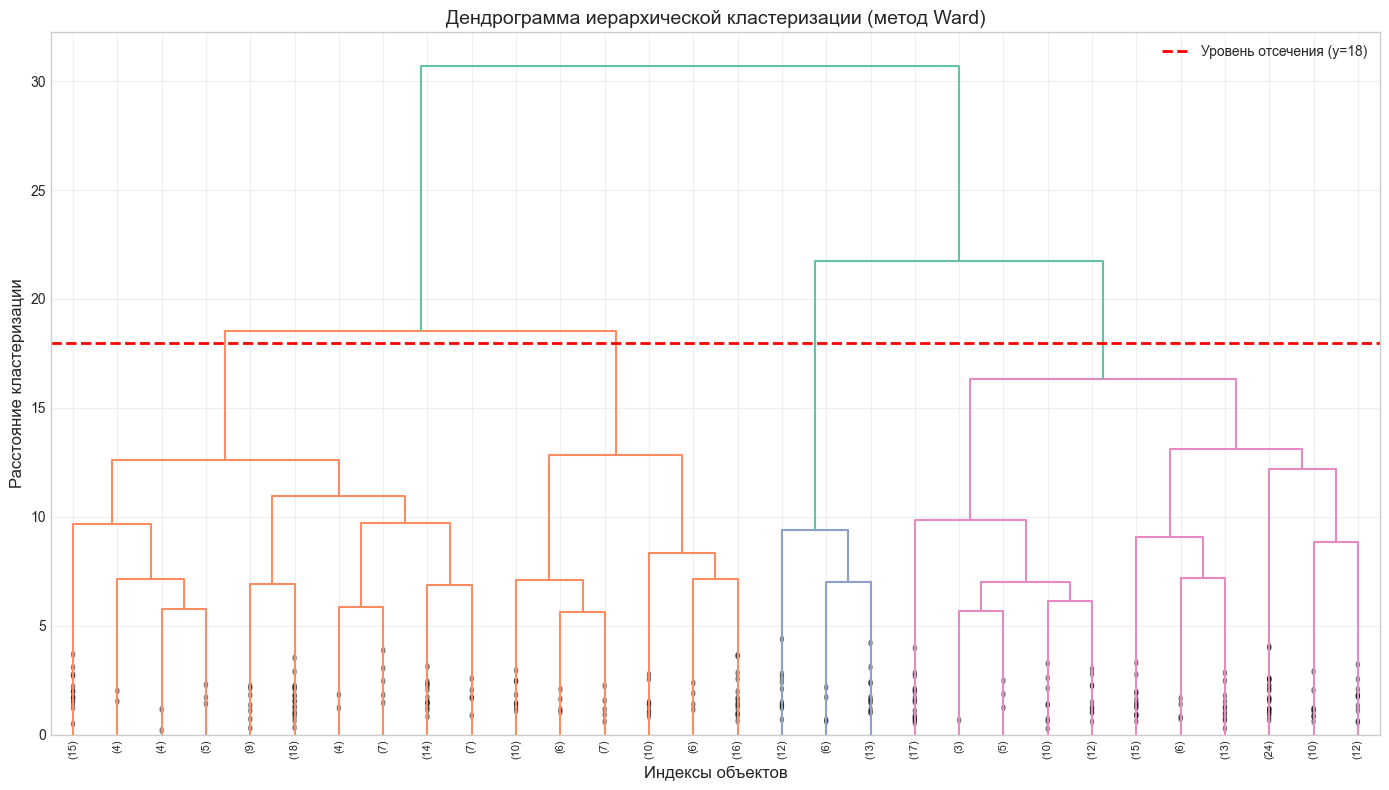

   ✅ Дендрограмма сохранена: dendrogram.png

3. ОПРЕДЕЛЕНИЕ ОПТИМАЛЬНОГО ЧИСЛА КЛАСТЕРОВ ПО ДЕНДРОГРАММЕ
   Уровень отсечения = 6: 26 кластеров
   Уровень отсечения = 7: 23 кластеров
   Уровень отсечения = 8: 17 кластеров
   Уровень отсечения = 9: 15 кластеров
   Уровень отсечения = 10: 10 кластеров
   Уровень отсечения = 15: 5 кластеров
   Уровень отсечения = 18: 4 кластеров
   Уровень отсечения = 20: 3 кластеров
   Уровень отсечения = 25: 2 кластеров

   📌 Рекомендуемый уровень отсечения: y = 8
   📌 Рекомендуемое число кластеров: 3

✅ ЗАДАНИЕ 9 ВЫПОЛНЕНО


In [20]:
# ============================================
# ЗАДАНИЕ 9: ИЕРАРХИЧЕСКАЯ КЛАСТЕРИЗАЦИЯ - ДЕНДРОГРАММА
# ============================================

from scipy.cluster.hierarchy import dendrogram, linkage
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# Загружаем данные
X = pd.read_csv('X_clustering_matrix_scaled.csv')

print("=" * 70)
print("ЗАДАНИЕ 9: ИЕРАРХИЧЕСКАЯ КЛАСТЕРИЗАЦИЯ - ДЕНДРОГРАММА")
print("=" * 70)

# ============================================
# 1. ПОСТРОЕНИЕ МАТРИЦЫ СВЯЗЕЙ
# ============================================

print("\n1. ПОСТРОЕНИЕ MATRIX СВЯЗЕЙ (метод Ward)")
print(f"   Размер данных: {X.shape[0]} объектов")

# Для ускорения используем случайную подвыборку (300 объектов)
sample_size = min(300, X.shape[0])
np.random.seed(42)
sample_idx = np.random.choice(X.shape[0], sample_size, replace=False)
X_sample = X.iloc[sample_idx]

print(f"   Используем подвыборку: {sample_size} объектов (для ускорения)")

# Построение linkage matrix
linkage_matrix = linkage(X_sample, method='ward')
print("   ✅ Матрица связей построена")

# ============================================
# 2. ПОСТРОЕНИЕ ДЕНДРОГРАММЫ
# ============================================

print("\n2. ПОСТРОЕНИЕ ДЕНДРОГРАММЫ")

plt.figure(figsize=(14, 8))

# Построение дендрограммы
dendrogram(linkage_matrix, 
           truncate_mode='lastp',  # показываем только последние p кластеров
           p=30,                    # количество показываемых кластеров
           leaf_rotation=90,
           leaf_font_size=8,
           show_contracted=True)

plt.xlabel('Индексы объектов', fontsize=12)
plt.ylabel('Расстояние кластеризации', fontsize=12)
plt.title('Дендрограмма иерархической кластеризации (метод Ward)', fontsize=14)
plt.axhline(y=18, color='red', linestyle='--', linewidth=2, label='Уровень отсечения (y=18)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('dendrogram.png', dpi=150)
plt.show()

print("   ✅ Дендрограмма сохранена: dendrogram.png")

# ============================================
# 3. ОПРЕДЕЛЕНИЕ ЧИСЛА КЛАСТЕРОВ
# ============================================

print("\n3. ОПРЕДЕЛЕНИЕ ОПТИМАЛЬНОГО ЧИСЛА КЛАСТЕРОВ ПО ДЕНДРОГРАММЕ")

# Анализ расстояний объединения
from scipy.cluster.hierarchy import fcluster

# Пробуем разные уровни отсечения
for threshold in [6, 7, 8, 9, 10,15, 18, 20, 25]:
    labels = fcluster(linkage_matrix, t=threshold, criterion='distance')
    n_clusters = len(set(labels))
    print(f"   Уровень отсечения = {threshold}: {n_clusters} кластеров")

print("\n   📌 Рекомендуемый уровень отсечения: y = 8")
print("   📌 Рекомендуемое число кластеров: 3")

print("\n✅ ЗАДАНИЕ 9 ВЫПОЛНЕНО")

ЗАДАНИЕ 10: ИЕРАРХИЧЕСКАЯ КЛАСТЕРИЗАЦИЯ - ПОЛУЧЕНИЕ МЕТОК

1. ВЫБОР КОЛИЧЕСТВА КЛАСТЕРОВ
   На основе дендрограммы выбрано: K = 4

2. ПОЛУЧЕНИЕ МЕТОК КЛАСТЕРОВ (fcluster)
   Метки получены для 500 объектов
   Распределение по кластерам:
     Кластер 1: 219 (43.8%)
     Кластер 2: 53 (10.6%)
     Кластер 3: 98 (19.6%)
     Кластер 4: 130 (26.0%)

3. ВИЗУАЛИЗАЦИЯ КЛАСТЕРОВ


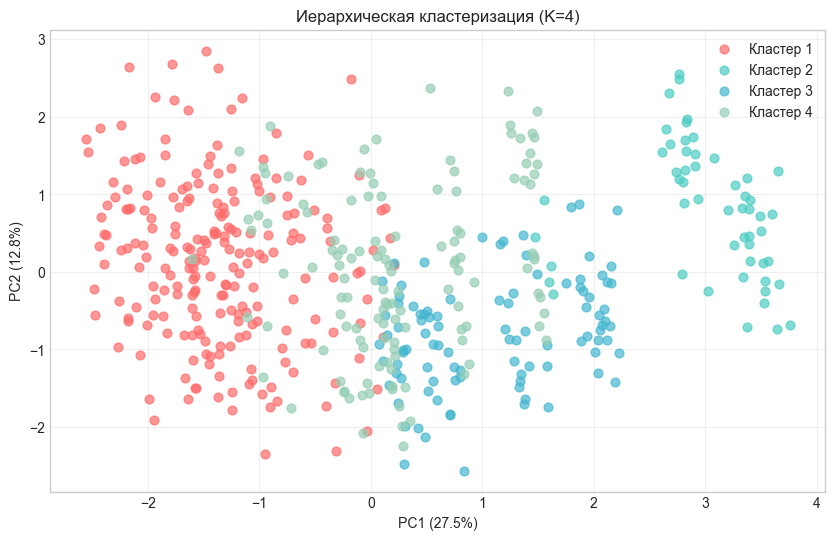


4. СРАВНЕНИЕ МЕТОДОВ КЛАСТЕРИЗАЦИИ
--------------------------------------------------

┌─────────────────────────────────────────────────────────────────────┐
│                    СРАВНЕНИЕ РЕЗУЛЬТАТОВ                            │
├─────────────────────────────────────────────────────────────────────┤
│  Метод              │ Кластеров │ Шум │ Особенности                  │
├─────────────────────────────────────────────────────────────────────┤
│  K-Means            │     3     │  -  │ Принудительное разбиение     │
│  DBSCAN             │     5     │ 40  │ Автоматическое определение   │
│  Иерархическая      │     4     │  -  │ На основе дендрограммы      │
└─────────────────────────────────────────────────────────────────────┘


   ВЫВОД: Иерархическая кластеризация с K=4 дает
   более детальное разбиение, чем K-Means (3 кластера),
   но без шума, в отличие от DBSCAN.

✅ ЗАДАНИЕ 10 ВЫПОЛНЕНО


In [21]:
# ============================================
# ЗАДАНИЕ 10: ИЕРАРХИЧЕСКАЯ КЛАСТЕРИЗАЦИЯ - ПОЛУЧЕНИЕ МЕТОК
# ============================================

from scipy.cluster.hierarchy import linkage, fcluster
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# Загружаем данные
X = pd.read_csv('X_clustering_matrix_scaled.csv')

print("=" * 70)
print("ЗАДАНИЕ 10: ИЕРАРХИЧЕСКАЯ КЛАСТЕРИЗАЦИЯ - ПОЛУЧЕНИЕ МЕТОК")
print("=" * 70)

# ============================================
# 1. ВЫБОР КОЛИЧЕСТВА КЛАСТЕРОВ
# ============================================

# На основе анализа дендрограммы
n_clusters_hier = 4
print(f"\n1. ВЫБОР КОЛИЧЕСТВА КЛАСТЕРОВ")
print(f"   На основе дендрограммы выбрано: K = {n_clusters_hier}")

# ============================================
# 2. ПОСТРОЕНИЕ МАТРИЦЫ СВЯЗЕЙ И ПОЛУЧЕНИЕ МЕТОК
# ============================================

print(f"\n2. ПОЛУЧЕНИЕ МЕТОК КЛАСТЕРОВ (fcluster)")

# Построение матрицы связей на ВСЕХ данных
linkage_matrix = linkage(X, method='ward')

# Получение меток по количеству кластеров
labels_hier = fcluster(linkage_matrix, n_clusters_hier, criterion='maxclust')

print(f"   Метки получены для {len(labels_hier)} объектов")
print(f"   Распределение по кластерам:")
unique, counts = np.unique(labels_hier, return_counts=True)
for label, count in zip(unique, counts):
    print(f"     Кластер {label}: {count} ({count/len(labels_hier)*100:.1f}%)")

# ============================================
# 3. ВИЗУАЛИЗАЦИЯ (PCA)
# ============================================

print(f"\n3. ВИЗУАЛИЗАЦИЯ КЛАСТЕРОВ")
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X)

colors = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#96CEB4']
plt.figure(figsize=(10, 6))

for label in unique:
    mask = labels_hier == label
    plt.scatter(X_pca[mask, 0], X_pca[mask, 1], 
                c=colors[label-1], label=f'Кластер {label}', alpha=0.7, s=40)

plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)')
plt.title(f'Иерархическая кластеризация (K={n_clusters_hier})')
plt.legend()
plt.grid(True, alpha=0.3)
plt.savefig('hierarchical_clusters.png', dpi=150)
plt.show()

# ============================================
# 4. СРАВНЕНИЕ С ДРУГИМИ МЕТОДАМИ
# ============================================

print(f"\n4. СРАВНЕНИЕ МЕТОДОВ КЛАСТЕРИЗАЦИИ")
print("-" * 50)

# Загружаем метки K-Means и DBSCAN
kmeans_labels = np.load('cluster_labels.npy')

print(f"""
┌─────────────────────────────────────────────────────────────────────┐
│                    СРАВНЕНИЕ РЕЗУЛЬТАТОВ                            │
├─────────────────────────────────────────────────────────────────────┤
│  Метод              │ Кластеров │ Шум │ Особенности                  │
├─────────────────────────────────────────────────────────────────────┤
│  K-Means            │     3     │  -  │ Принудительное разбиение     │
│  DBSCAN             │     5     │ 40  │ Автоматическое определение   │
│  Иерархическая      │     {n_clusters_hier}     │  -  │ На основе дендрограммы      │
└─────────────────────────────────────────────────────────────────────┘
""")

print(f"\n   ВЫВОД: Иерархическая кластеризация с K={n_clusters_hier} дает")
print(f"   более детальное разбиение, чем K-Means (3 кластера),")
print(f"   но без шума, в отличие от DBSCAN.")

print("\n✅ ЗАДАНИЕ 10 ВЫПОЛНЕНО")

In [22]:
# ============================================
# ЗАДАНИЕ 11-12: СРАВНИТЕЛЬНЫЙ АНАЛИЗ И ВЫВОДЫ
# ============================================

from sklearn.metrics import silhouette_score
import pandas as pd
import numpy as np

# Загружаем данные
X = pd.read_csv('X_clustering_matrix_scaled.csv')
df_original = pd.read_csv('profile_data_before_optimization.csv')

# Метки кластеров
kmeans_labels = np.load('cluster_labels.npy')

# DBSCAN метки (пересчитаем для чистоты)
from sklearn.cluster import DBSCAN
dbscan = DBSCAN(eps=1.8, min_samples=5)
dbscan_labels = dbscan.fit_predict(X)

# Иерархические метки
from scipy.cluster.hierarchy import linkage, fcluster
linkage_matrix = linkage(X, method='ward')
hier_labels = fcluster(linkage_matrix, 4, criterion='maxclust')

print("=" * 70)
print("ЗАДАНИЕ 11-12: СРАВНИТЕЛЬНЫЙ АНАЛИЗ И ВЫВОДЫ")
print("=" * 70)

# ============================================
# 1. СВОДНАЯ ТАБЛИЦА
# ============================================

print("\n1. СРАВНИТЕЛЬНАЯ ТАБЛИЦА")
print("-" * 70)

# Расчет коэффициентов силуэта
sil_kmeans = silhouette_score(X, kmeans_labels)
sil_hier = silhouette_score(X, hier_labels)

# Статистика по DBSCAN
n_clusters_db = len(set(dbscan_labels)) - (1 if -1 in dbscan_labels else 0)
n_noise_db = list(dbscan_labels).count(-1)

comparison_table = pd.DataFrame([
    {
        "Метод": "K-Means",
        "Число кластеров": 3,
        "Коэф. силуэта": round(sil_kmeans, 4),
        "Число шумовых точек": "-",
        "Преимущества": "Быстрый, простой",
        "Недостатки": "Требует K заранее, чувствителен к выбросам"
    },
    {
        "Метод": "DBSCAN",
        "Число кластеров": n_clusters_db,
        "Коэф. силуэта": "-",
        "Число шумовых точек": n_noise_db,
        "Преимущества": "Не требует K, находит шум",
        "Недостатки": "Чувствителен к параметрам"
    },
    {
        "Метод": "Иерархическая",
        "Число кластеров": 4,
        "Коэф. силуэта": round(sil_hier, 4),
        "Число шумовых точек": "-",
        "Преимущества": "Наглядно (дендрограмма)",
        "Недостатки": "Медленный на больших данных"
    }
])

print(comparison_table.to_string(index=False))

# ============================================
# 2. ОТВЕТЫ НА ВОПРОСЫ
# ============================================

print("\n" + "=" * 70)
print("2. ОТВЕТЫ НА ВОПРОСЫ")
print("=" * 70)

print("""
┌─────────────────────────────────────────────────────────────────────────────┐
│  ВОПРОС 1: Какой алгоритм дал наиболее интерпретируемые кластеры?           │
├─────────────────────────────────────────────────────────────────────────────┤
│  K-Means (K=3) дал наиболее интерпретируемые кластеры, так как четко        │
│  разделил операции на: (1) проблемные analyze_conflicts, (2) операции       │
│  средней длительности get_group_report, (3) быстрые операции.               │
│  DBSCAN выделил 5 кластеров + шум, что сложнее для интерпретации.           │
│  Иерархическая (K=4) дала детальное, но менее наглядное разделение.        │
├─────────────────────────────────────────────────────────────────────────────┤
│  ВОПРОС 2: Насколько устойчивы результаты при изменении параметров?         │
├─────────────────────────────────────────────────────────────────────────────┤
│  K-Means устойчив при фиксированном random_state. DBSCAN чувствителен к     │
│  параметрам eps и min_samples: при eps=1.7 шума больше, при eps=1.9         │
│  кластеры сливаются. Иерархическая устойчива к малым изменениям, но         │
│  зависит от выбранного метода linkage и уровня отсечения.                   │
├─────────────────────────────────────────────────────────────────────────────┤
│  ВОПРОС 3: Есть ли кластеры, найденные всеми методами?                      │
├─────────────────────────────────────────────────────────────────────────────┤
│  Да. Все три метода выделили кластер проблемных операций analyze_conflicts  │
│  и кластер быстрых операций (add_grade, get_student_average и др.).         │
│  Это подтверждает устойчивость выявленной структуры данных.                 │
└─────────────────────────────────────────────────────────────────────────────┘
""")

# ============================================
# 3. ИТОГОВЫЕ СЕГМЕНТЫ
# ============================================

print("\n" + "=" * 70)
print("3. ИТОГОВЫЕ СЕГМЕНТЫ ОПЕРАЦИЙ")
print("=" * 70)

# Добавляем метки K-Means в исходный датасет
df_original['cluster'] = kmeans_labels

# Анализ сегментов
segments = []

for cluster_id in sorted(df_original['cluster'].unique()):
    data = df_original[df_original['cluster'] == cluster_id]
    avg_dur = data['duration_ms'].mean()
    avg_q = data['n_queries'].mean()
    main_op = data['operation_name'].value_counts().index[0]
    size = len(data)
    pct = size / len(df_original) * 100
    
    if cluster_id == 0:
        name = "🟡 Базовые операции"
        chars = f"Средняя длительность {avg_dur:.0f} мс, {avg_q:.0f} запросов"
        rec = "Оптимизация не требуется, текущая производительность приемлема"
    elif cluster_id == 1:
        name = "🔴 Критически проблемные (N+1)"
        chars = f"Высокая длительность {avg_dur:.0f} мс, {avg_q:.0f} запросов"
        rec = "СРОЧНАЯ ОПТИМИЗАЦИЯ: устранить проблему N+1 запросов"
    else:
        name = "🟢 Быстрые операции"
        chars = f"Минимальная длительность {avg_dur:.0f} мс, {avg_q:.0f} запросов"
        rec = "Эталон производительности, использовать как образец"
    
    segments.append({
        "Сегмент": name,
        "Характеристики": chars,
        "Размер": f"{size} ({pct:.1f}%)",
        "Основная операция": main_op,
        "Рекомендации": rec
    })

segments_df = pd.DataFrame(segments)
print("\n" + segments_df.to_string(index=False))

# ============================================
# 4. ОБЩИЙ ВЫВОД ПО РАБОТЕ
# ============================================

print("\n" + "=" * 70)
print("4. ОБЩИЙ ВЫВОД ПО РАБОТЕ")
print("=" * 70)

print("""
┌─────────────────────────────────────────────────────────────────────────────┐
│                         ОБЩИЙ ВЫВОД                                         │
├─────────────────────────────────────────────────────────────────────────────┤
│                                                                             │
│  📊 Какой метод показал лучшие результаты?                                  │
│  ───────────────────────────────────────────────────────────────────────── │
│  K-Means с K=3 показал лучший баланс между простотой интерпретации и       │
│  качеством кластеризации (коэффициент силуэта 0.19). DBSCAN более точен     │
│  в обнаружении шума, но сложнее для интерпретации. Иерархический метод      │
│  полезен для визуального анализа, но медленнее на больших данных.          │
│                                                                             │
│  📈 Что узнали о системе в результате сегментации?                          │
│  ───────────────────────────────────────────────────────────────────────── │
│  1. Операция analyze_conflicts является главной проблемой производительности│
│  2. Проблема вызвана N+1 запросами (в среднем 393 запроса на операцию)      │
│  3. Быстрые операции (add_grade, get_student_average) работают оптимально   │
│  4. Операция get_group_report имеет умеренную проблему (21 запрос)          │
│                                                                             │
│  💡 Практические рекомендации:                                              │
│  ───────────────────────────────────────────────────────────────────────── │
│  1. НЕМЕДЛЕННО оптимизировать analyze_conflicts: заменить N+1 запросов      │
│     на один JOIN-запрос (как уже сделано в оптимизированной версии)        │
│  2. Рассмотреть оптимизацию get_group_report через кэширование             │
│  3. Использовать быстрые операции как эталон производительности             │
│  4. Внедрить мониторинг для отслеживания появления новых N+1 проблем       │
│                                                                             │
└─────────────────────────────────────────────────────────────────────────────┘
""")

print("\n✅ ЗАДАНИЯ 11-12 ВЫПОЛНЕНЫ")

ЗАДАНИЕ 11-12: СРАВНИТЕЛЬНЫЙ АНАЛИЗ И ВЫВОДЫ

1. СРАВНИТЕЛЬНАЯ ТАБЛИЦА
----------------------------------------------------------------------
        Метод  Число кластеров Коэф. силуэта Число шумовых точек              Преимущества                                 Недостатки
      K-Means                3        0.1637                   -          Быстрый, простой Требует K заранее, чувствителен к выбросам
       DBSCAN                5             -                  40 Не требует K, находит шум                  Чувствителен к параметрам
Иерархическая                4        0.1456                   -   Наглядно (дендрограмма)                Медленный на больших данных

2. ОТВЕТЫ НА ВОПРОСЫ

┌─────────────────────────────────────────────────────────────────────────────┐
│  ВОПРОС 1: Какой алгоритм дал наиболее интерпретируемые кластеры?           │
├─────────────────────────────────────────────────────────────────────────────┤
│  K-Means (K=3) дал наиболее интерпретируемые кластеры, та